# Load Data
Decided to just grab all the data in this one and manually manipulate it for binary features


In [1]:
import pybaseball as pb

pitch_data = pb.statcast("2025-01-01", "2025-9-30")
filename = f"statcast_all_cols_2025.csv"
pitch_data.to_csv(filename, index=False)
print(f"Data saved to {filename}")

This is a large query, it may take a moment to complete


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates


  0%|          | 1/200 [00:00<00:47,  4.18it/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
  1%|          | 2/200 [00:00<01:43,  1.91it/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
  2%|▏         | 3/200 [00:01<01:16,  2.56it/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseb

Data saved to statcast_all_cols_2025.csv


In [2]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('statcast_all_cols_2025.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: (757689, 118)

Column names:
['pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 'release_extension', 'game_pk', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 'woba_value', 'woba_denom',

# Filter Columns Function
Create a function to keep only the relevant columns

In [3]:
def add_pitch_type_one_hot(dataframe, pitch_type_column='pitch_type'):
    """
    Add one-hot encoded columns for each unique pitch type.
    Pitch types with less than 1000 occurrences are grouped into 'other'.
    
    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        pitch_type_column (str): Name of the column containing pitch types. Default is 'pitch_type'.
    
    Returns:
        pd.DataFrame: A new DataFrame with one-hot encoded pitch type columns added.
    """
    df_with_features = dataframe.copy()
    
    # Get unique pitch types (excluding NaN values)
    unique_pitch_types = df_with_features[pitch_type_column].dropna().unique()
    print(f"Found {len(unique_pitch_types)} unique pitch types: {sorted(unique_pitch_types)}")
    
    # Count occurrences of each pitch type
    pitch_type_counts = df_with_features[pitch_type_column].value_counts()
    
    # Separate pitch types into common and rare
    common_pitch_types = pitch_type_counts[pitch_type_counts >= 1000].index.tolist()
    rare_pitch_types = pitch_type_counts[pitch_type_counts < 1000].index.tolist()
    
    print(f"Common pitch types (>= 1000): {sorted(common_pitch_types)}")
    print(f"Rare pitch types (< 1000, grouped as 'other'): {sorted(rare_pitch_types)}")
    
    # Create one-hot encoded columns for common pitch types
    for pitch_type in common_pitch_types:
        column_name = f"pitch_type_{pitch_type}"
        df_with_features[column_name] = (df_with_features[pitch_type_column] == pitch_type).astype(int)
    
    # Create one-hot encoded column for 'other' if there are rare pitch types
    if rare_pitch_types:
        df_with_features['pitch_type_other'] = df_with_features[pitch_type_column].isin(rare_pitch_types).astype(int)
    
    print(f"Added {len(common_pitch_types) + (1 if rare_pitch_types else 0)} one-hot encoded columns for pitch types")
    
    return df_with_features

In [4]:
def add_count_one_hot(dataframe, balls_column='balls', strikes_column='strikes'):
    """
    Add one-hot encoded columns for each unique ball-strike count.
    
    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        balls_column (str): Name of the column containing ball counts. Default is 'balls'.
        strikes_column (str): Name of the column containing strike counts. Default is 'strikes'.
    
    Returns:
        pd.DataFrame: A new DataFrame with one-hot encoded count columns added.
    """
    df_with_features = dataframe.copy()
    
    
    # Create a combined count column (e.g., "0-0", "1-2", "3-2")
    df_with_features['count'] = df_with_features[balls_column].astype(str) + '-' + df_with_features[strikes_column].astype(str)
    
    # Get unique counts (excluding NaN values)
    unique_counts = df_with_features['count'].dropna().unique()
    print(f"Found {len(unique_counts)} unique counts: {sorted(unique_counts)}")
    
    # Create one-hot encoded columns for each count
    for count in unique_counts:
        column_name = f"count_{count}"
        # filter out invalid counts
        if len(count) == 3 and int(count[0]) < 4 and int(count[2]) < 3:  
            df_with_features[column_name] = (df_with_features['count'] == count).astype(int)
    
    print(f"Added {len(unique_counts)} one-hot encoded columns for counts")
    
    # Drop the temporary 'count' column
    df_with_features = df_with_features.drop('count', axis=1)
    
    return df_with_features

In [5]:
def add_handedness_one_hot(dataframe, batter_column='stand', pitcher_column='p_throws'):
    """
    Add a matchup column indicating if pitcher and batter have opposite handedness.
    
    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        batter_column (str): Name of the column containing batter handedness. Default is 'stand'.
        pitcher_column (str): Name of the column containing pitcher handedness. Default is 'p_throws'.
    
    Returns:
        pd.DataFrame: A new DataFrame with matchup column added.
    """
    df_with_features = dataframe.copy()
    
    # Create matchup column: 1 if different handedness, 0 if same
    df_with_features['matchup'] = (df_with_features[batter_column] != df_with_features[pitcher_column]).astype(int)
    print(f"Added matchup column: 1 if pitcher and batter have opposite handedness, 0 if same")
    
    # Multiply release_pos_x by -1 for left-handed pitchers to prevent handedness leakage
    if 'release_pos_x' in df_with_features.columns:
        lefty_mask = df_with_features[pitcher_column] == 'L'
        df_with_features.loc[lefty_mask, 'release_pos_x'] = df_with_features.loc[lefty_mask, 'release_pos_x'] * -1
        print(f"Multiplied release_pos_x by -1 for left-handed pitchers to prevent handedness leakage")
    
    return df_with_features


# Apply all feature engineering functions
df_with_features = add_pitch_type_one_hot(df)
df_with_features = add_count_one_hot(df_with_features)
df_with_features = add_handedness_one_hot(df_with_features)

# Display the new columns
print("\nPitch type columns:")
pitch_type_columns = [col for col in df_with_features.columns if col.startswith('pitch_type_')]
print(pitch_type_columns)

print("\nCount columns:")
count_columns = [col for col in df_with_features.columns if col.startswith('count_')]
print(count_columns)

print("\nHandedness columns:")
handedness_columns = [col for col in df_with_features.columns if 'hand' in col.lower() or col == 'matchup']
print(handedness_columns)

# Show a sample of the data with the new features
print("\nSample data with one-hot encoded features:")
display_cols = ['player_name', 'pitch_type', 'stand', 'p_throws'] + pitch_type_columns[:2] + count_columns[:2] + handedness_columns
df_with_features[display_cols].head(10)

Found 18 unique pitch types: ['CH', 'CS', 'CU', 'EP', 'FA', 'FC', 'FF', 'FO', 'FS', 'KC', 'KN', 'PO', 'SC', 'SI', 'SL', 'ST', 'SV', 'UN']
Common pitch types (>= 1000): ['CH', 'CU', 'FC', 'FF', 'FS', 'KC', 'SI', 'SL', 'ST', 'SV']
Rare pitch types (< 1000, grouped as 'other'): ['CS', 'EP', 'FA', 'FO', 'KN', 'PO', 'SC', 'UN']
Added 11 one-hot encoded columns for pitch types
Found 16 unique counts: ['0-0', '0-1', '0-2', '0-3', '1-0', '1-1', '1-2', '1-3', '2-0', '2-1', '2-2', '3-0', '3-1', '3-2', '4-2', '4-3']
Added 16 one-hot encoded columns for counts
Added matchup column: 1 if pitcher and batter have opposite handedness, 0 if same
Multiplied release_pos_x by -1 for left-handed pitchers to prevent handedness leakage

Pitch type columns:
['pitch_type_FF', 'pitch_type_SI', 'pitch_type_SL', 'pitch_type_CH', 'pitch_type_FC', 'pitch_type_CU', 'pitch_type_ST', 'pitch_type_FS', 'pitch_type_KC', 'pitch_type_SV', 'pitch_type_other']

Count columns:
['count_2-2', 'count_2-1', 'count_1-1', 'count_1-

,player_name,pitch_type,stand,p_throws,pitch_type_FF,pitch_type_SI,count_2-2,count_2-1,matchup
0,"Chapman, Aroldis",FF,L,L,1,0,1,0,0
1,"Chapman, Aroldis",SL,L,L,0,0,0,1,0
2,"Chapman, Aroldis",FF,L,L,1,0,0,0,0
3,"Chapman, Aroldis",FF,L,L,1,0,0,0,0
4,"Chapman, Aroldis",FF,L,L,1,0,0,0,0
5,"Chapman, Aroldis",SL,L,L,0,0,0,0,0
6,"Chapman, Aroldis",FF,L,L,1,0,0,0,0
7,"Chapman, Aroldis",FF,L,L,1,0,0,0,0
8,"Chapman, Aroldis",FF,L,L,1,0,0,0,0
9,"Chapman, Aroldis",FS,R,L,0,0,0,0,1


# Feature Engineering
Add one-hot encoded features for pitch types

In [6]:
def filter_columns(dataframe, columns_to_keep, min_pitch_count=None, pitcher_column='player_name'):
    """
    Filter a DataFrame to keep only the specified columns and optionally filter by minimum pitch count.
    
    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        columns_to_keep (list): List of column names to keep.
        min_pitch_count (int, optional): Minimum number of pitches a pitcher must have thrown to be included.
        pitcher_column (str): Name of the column containing pitcher names. Default is 'player_name'.
    
    Returns:
        pd.DataFrame: A new DataFrame with only the specified columns and filtered by pitch count.
    """
    # Check which columns exist in the dataframe
    available_columns = [col for col in columns_to_keep if col in dataframe.columns]
    missing_columns = [col for col in columns_to_keep if col not in dataframe.columns]
    
    if missing_columns:
        print(f"Warning: The following columns were not found: {missing_columns}")
    
    # Filter by columns first
    df_filtered = dataframe[available_columns].copy()
    
    # Apply minimum pitch count filter if specified
    if min_pitch_count is not None and pitcher_column in df_filtered.columns:
        pitch_counts = df_filtered[pitcher_column].value_counts()
        pitchers_to_keep = pitch_counts[pitch_counts >= min_pitch_count].index
        
        original_count = len(df_filtered)
        df_filtered = df_filtered[df_filtered[pitcher_column].isin(pitchers_to_keep)]
        
        print(f"Filtered out {len(pitch_counts) - len(pitchers_to_keep)} pitchers with fewer than {min_pitch_count} pitches")
        print(f"Removed {original_count - len(df_filtered)} rows")
        print(f"Remaining pitchers: {len(pitchers_to_keep)}")

    # Spin axis correction (do this BEFORE dropping handedness column if applicable)
    # Align left-handed pitchers' spin_axis to right-handed convention:
    # if spin_axis > 180 -> 180 - spin_axis + 360; else -> 180 - spin_axis
    if {'spin_axis', 'p_throws'}.issubset(df_filtered.columns):
        lhp_mask = df_filtered['p_throws'].eq('L')
        if lhp_mask.any():
            spin = pd.to_numeric(df_filtered.loc[lhp_mask, 'spin_axis'], errors='coerce')
            adjusted = (180 - spin) % 360
            df_filtered.loc[lhp_mask, 'spin_axis'] = adjusted
        else:
            # No LHP rows present, nothing to adjust
            pass
        # drop the 'p_throws' column after (we don't want the model to have access to it)
        df_filtered = df_filtered.drop('p_throws', axis=1)
    else:
        print("Spin axis correction skipped: missing 'p_throws' or 'spin_axis' column.")
    
    return df_filtered


# Change this based on what we're doing
# Note that 'p_throws' is kept, but we do drop it anyways (we only need it to adjust spin axis)
columns_to_keep = [
    'player_name',
    'release_speed',
    'release_pos_x',
    'release_pos_z',
    'pfx_x',
    'pfx_z',
    'plate_x',
    'plate_z',
    'release_spin',
    'spin_axis',
    'p_throws'
]

# Add all one-hot encoded pitch type columns to the list
pitch_type_one_hot_cols = [col for col in df_with_features.columns if col.startswith('pitch_type_')]
columns_to_keep.extend(pitch_type_one_hot_cols)

# Add all one-hot encoded count columns to the list
count_one_hot_cols = [col for col in df_with_features.columns if col.startswith('count_')]
columns_to_keep.extend(count_one_hot_cols)

# Add the matchup column
if 'matchup' in df_with_features.columns:
    columns_to_keep.append('matchup')

# Apply the filter function with minimum pitch count
df_filtered = filter_columns(df_with_features, columns_to_keep, min_pitch_count=2000)

print(f"\nFiltered dataset shape: {df_filtered.shape}")
print(f"\nFiltered columns:")
print(df_filtered.columns.tolist())
df_filtered.head()

Filtered out 1091 pitchers with fewer than 2000 pitches
Removed 464122 rows
Remaining pitchers: 110

Filtered dataset shape: (293567, 33)

Filtered columns:
['player_name', 'release_speed', 'release_pos_x', 'release_pos_z', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'spin_axis', 'pitch_type_FF', 'pitch_type_SI', 'pitch_type_SL', 'pitch_type_CH', 'pitch_type_FC', 'pitch_type_CU', 'pitch_type_ST', 'pitch_type_FS', 'pitch_type_KC', 'pitch_type_SV', 'pitch_type_other', 'count_2-2', 'count_2-1', 'count_1-1', 'count_1-0', 'count_0-0', 'count_0-2', 'count_0-1', 'count_1-2', 'count_3-2', 'count_3-0', 'count_2-0', 'count_3-1', 'matchup']


,player_name,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,plate_x,plate_z,spin_axis,pitch_type_FF,...,count_1-0,count_0-0,count_0-2,count_0-1,count_1-2,count_3-2,count_3-0,count_2-0,count_3-1,matchup
43,"Crochet, Garrett",100.2,-2.41,5.92,1.26,0.85,0.47,1.84,45.0,0,...,0,0,0,0,0,1,0,0,0,0
44,"Crochet, Garrett",97.3,-2.49,6.10,0.58,1.21,1.69,4.42,38.0,1,...,0,0,0,0,0,0,0,0,0,0
45,"Crochet, Garrett",98.6,-2.20,6.06,0.97,0.82,-0.79,2.64,41.0,0,...,0,0,0,0,1,0,0,0,0,0
46,"Crochet, Garrett",85.3,-1.98,6.29,-1.21,-0.29,-0.47,2.72,244.0,0,...,0,0,0,0,1,0,0,0,0,0
47,"Crochet, Garrett",98.0,-2.14,6.12,0.41,1.21,-0.65,4.39,38.0,1,...,0,0,1,0,0,0,0,0,0,0


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# set up MLP for pitcher classification
class PitcherClassifier(nn.Module):
    """A simple feedforward neural network for pitcher classification.
    2 layers with ReLU activations and dropout for regularization.
    Args:
        num_features (int): Number of input features.
        num_pitchers (int): Number of unique pitchers (output classes).
        hidden1 (int): Number of neurons in the first hidden layer.
        hidden2 (int): Number of neurons in the second hidden layer.
        dropout_rate (float): Dropout rate for regularization.
    """
    def __init__(self, num_features, num_pitchers, hidden1=128, hidden2=64, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(num_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.dropout = nn.Dropout(dropout_rate)
        self.out = nn.Linear(hidden2, num_pitchers)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.out(x)
    

Here we train the MLP. Current accuracy is like .83 with 50 epochs. Haven't evaluated it on other metrics yet.

In [8]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Prepare the data
df_filtered = df_filtered.dropna()

# Encode pitcher names as labels
le = LabelEncoder()
y = le.fit_transform(df_filtered['player_name'])

# Drop the player_name column to get features only
X = df_filtered.drop(columns=['player_name'])

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

# Create datasets and dataloaders
train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val, y_val)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=64, shuffle=False)

# Initialize model, optimizer, and loss function
model = PitcherClassifier(num_features=X_train.shape[1], num_pitchers=len(le.classes_))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Lists to track metrics
train_losses = []
val_losses = []
val_accuracies = []

# Training loop
for epoch in range(50):
    # Training
    model.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    # Calculate average training loss for this epoch
    avg_train_loss = epoch_train_loss / len(train_dl)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    epoch_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_dl:
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            epoch_val_loss += loss.item()
            
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    
    # Calculate average validation loss and accuracy
    avg_val_loss = epoch_val_loss / len(val_dl)
    val_acc = correct / total
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

print(f"\nFinal validation accuracy: {val_accuracies[-1]:.4f}")


Epoch 1: Train Loss = 1.7978, Val Loss = 1.0348, Val Acc = 0.6836
Epoch 2: Train Loss = 1.1792, Val Loss = 0.8723, Val Acc = 0.7260
Epoch 3: Train Loss = 1.0646, Val Loss = 0.7858, Val Acc = 0.7517
Epoch 4: Train Loss = 0.9987, Val Loss = 0.7374, Val Acc = 0.7646
Epoch 5: Train Loss = 0.9544, Val Loss = 0.7160, Val Acc = 0.7701
Epoch 6: Train Loss = 0.9219, Val Loss = 0.6815, Val Acc = 0.7830
Epoch 7: Train Loss = 0.8969, Val Loss = 0.6694, Val Acc = 0.7831
Epoch 8: Train Loss = 0.8793, Val Loss = 0.6488, Val Acc = 0.7910
Epoch 9: Train Loss = 0.8612, Val Loss = 0.6415, Val Acc = 0.7938
Epoch 10: Train Loss = 0.8472, Val Loss = 0.6277, Val Acc = 0.7970
Epoch 11: Train Loss = 0.8371, Val Loss = 0.6215, Val Acc = 0.7975
Epoch 12: Train Loss = 0.8278, Val Loss = 0.6179, Val Acc = 0.7978
Epoch 13: Train Loss = 0.8206, Val Loss = 0.6128, Val Acc = 0.8017
Epoch 14: Train Loss = 0.8110, Val Loss = 0.6089, Val Acc = 0.8015
Epoch 15: Train Loss = 0.8032, Val Loss = 0.5894, Val Acc = 0.8091
Epoc

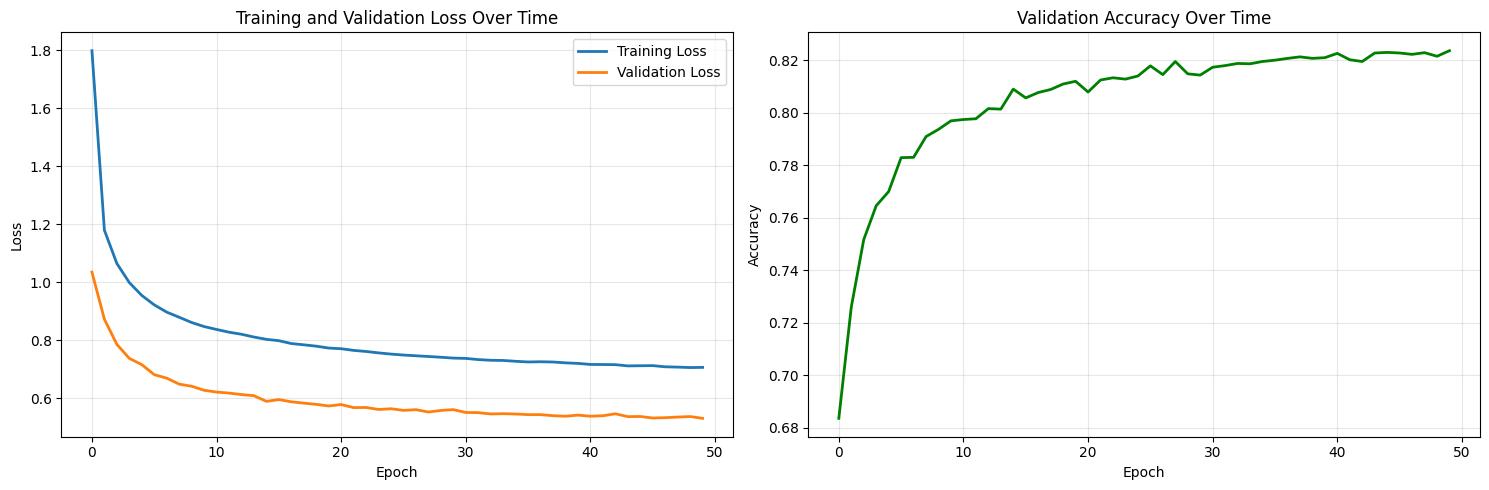

Top-1 Accuracy (Exact Match): 0.8237
Top-3 Accuracy: 0.9613
Top-5 Accuracy: 0.9850

Per-pitcher performance (sample):
  Abbott, Andrew: 0.875 accuracy (554 pitches)
  Alcantara, Sandy: 0.903 accuracy (578 pitches)
  Allen, Logan: 0.920 accuracy (526 pitches)
  Anderson, Tyler: 0.942 accuracy (468 pitches)
  Bassitt, Chris: 0.737 accuracy (600 pitches)
  Baz, Shane: 0.701 accuracy (541 pitches)
  Bello, Brayan: 0.873 accuracy (528 pitches)
  Berríos, José: 0.827 accuracy (548 pitches)
  Bibee, Tanner: 0.769 accuracy (623 pitches)
  Boyd, Matthew: 0.941 accuracy (561 pitches)
  Bradley, Taj: 0.802 accuracy (475 pitches)
  Brown, Hunter: 0.740 accuracy (592 pitches)
  Bubic, Kris: 0.817 accuracy (404 pitches)
  Buehler, Walker: 0.723 accuracy (451 pitches)
  Burke, Sean: 0.801 accuracy (507 pitches)
  Cabrera, Edward: 0.751 accuracy (450 pitches)
  Cameron, Noah: 0.771 accuracy (433 pitches)
  Castillo, Luis: 0.855 accuracy (614 pitches)
  Cease, Dylan: 0.753 accuracy (623 pitches)
  Cecc

In [9]:
# Visualize training progress
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training and validation loss
ax1.plot(train_losses, label='Training Loss', linewidth=2)
ax1.plot(val_losses, label='Validation Loss', linewidth=2)
ax1.set_title('Training and Validation Loss Over Time')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
ax2.plot(val_accuracies, color='green', linewidth=2)
ax2.set_title('Validation Accuracy Over Time')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on validation set with more metrics
from sklearn.metrics import top_k_accuracy_score

model.eval()
with torch.no_grad():
    val_logits = model(X_val)
    val_preds = val_logits.argmax(dim=1).numpy()
    val_probs = F.softmax(val_logits, dim=1).numpy()

# Top-k accuracy (how often the correct pitcher is in top k predictions)
top3_acc = top_k_accuracy_score(y_val.numpy(), val_probs, k=3)
top5_acc = top_k_accuracy_score(y_val.numpy(), val_probs, k=5)

print(f"Top-1 Accuracy (Exact Match): {val_accuracies[-1]:.4f}")
print(f"Top-3 Accuracy: {top3_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

# Show performance for a few example pitchers
print("\nPer-pitcher performance (sample):")
unique_pitchers = np.unique(y_val.numpy())  # All pitchers
for pitcher_id in unique_pitchers:
    pitcher_name = le.inverse_transform([pitcher_id])[0]
    pitcher_mask = y_val.numpy() == pitcher_id
    pitcher_acc = (val_preds[pitcher_mask] == pitcher_id).mean()
    pitcher_count = pitcher_mask.sum()
    print(f"  {pitcher_name}: {pitcher_acc:.3f} accuracy ({pitcher_count} pitches)")

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)

class PitchAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Train autoencoder
model = PitchAutoencoder(input_dim=X_train.shape[1], latent_dim=8)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("Training Autoencoder...")
ae_losses = []

for epoch in range(100):
    model.train()
    epoch_loss = 0.0
    for X_batch, _ in train_dl:  # Ignore labels, we only need features
        optimizer.zero_grad()
        x_hat, z = model(X_batch)
        loss = loss_fn(x_hat, X_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_dl)
    ae_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100, Reconstruction Loss: {avg_loss:.6f}")

print("\nAutoencoder training complete!")

# Extract latent representations for all validation data
model.eval()
with torch.no_grad():
    _, val_latent = model(X_val)
    val_latent = val_latent.numpy()

print(f"Latent representation shape: {val_latent.shape}")
print(f"Latent dim: {val_latent.shape[1]}")

Training Autoencoder...
Epoch 10/100, Reconstruction Loss: 0.053675
Epoch 20/100, Reconstruction Loss: 0.033857
Epoch 30/100, Reconstruction Loss: 0.029906
Epoch 40/100, Reconstruction Loss: 0.027632
Epoch 50/100, Reconstruction Loss: 0.026238
Epoch 60/100, Reconstruction Loss: 0.025106
Epoch 70/100, Reconstruction Loss: 0.024116
Epoch 80/100, Reconstruction Loss: 0.023427
Epoch 90/100, Reconstruction Loss: 0.022643
Epoch 100/100, Reconstruction Loss: 0.021719

Autoencoder training complete!
Latent representation shape: (57671, 8)
Latent dim: 8


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)

class PitchAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Train autoencoder
model = PitchAutoencoder(input_dim=X_train.shape[1], latent_dim=8)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("Training Autoencoder...")
ae_losses = []

for epoch in range(100):
    model.train()
    epoch_loss = 0.0
    for X_batch, _ in train_dl:  # Ignore labels, we only need features
        optimizer.zero_grad()
        x_hat, z = model(X_batch)
        loss = loss_fn(x_hat, X_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_dl)
    ae_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100, Reconstruction Loss: {avg_loss:.6f}")

print("\nAutoencoder training complete!")

# Extract latent representations for all validation data
model.eval()
with torch.no_grad():
    _, val_latent = model(X_val)
    val_latent = val_latent.numpy()

print(f"Latent representation shape: {val_latent.shape}")
print(f"Latent dim: {val_latent.shape[1]}")

Training Autoencoder...
Epoch 10/100, Reconstruction Loss: 0.044697
Epoch 10/100, Reconstruction Loss: 0.044697
Epoch 20/100, Reconstruction Loss: 0.027134
Epoch 20/100, Reconstruction Loss: 0.027134
Epoch 30/100, Reconstruction Loss: 0.025186
Epoch 30/100, Reconstruction Loss: 0.025186
Epoch 40/100, Reconstruction Loss: 0.020835
Epoch 40/100, Reconstruction Loss: 0.020835
Epoch 50/100, Reconstruction Loss: 0.020583
Epoch 50/100, Reconstruction Loss: 0.020583
Epoch 60/100, Reconstruction Loss: 0.019440
Epoch 60/100, Reconstruction Loss: 0.019440
Epoch 70/100, Reconstruction Loss: 0.019306
Epoch 70/100, Reconstruction Loss: 0.019306
Epoch 80/100, Reconstruction Loss: 0.019404
Epoch 80/100, Reconstruction Loss: 0.019404
Epoch 90/100, Reconstruction Loss: 0.021551
Epoch 90/100, Reconstruction Loss: 0.021551
Epoch 100/100, Reconstruction Loss: 0.017948

Autoencoder training complete!
Latent representation shape: (57668, 8)
Latent dim: 8
Epoch 100/100, Reconstruction Loss: 0.017948

Autoenc

## Autoencoder Latent Space Visualizations

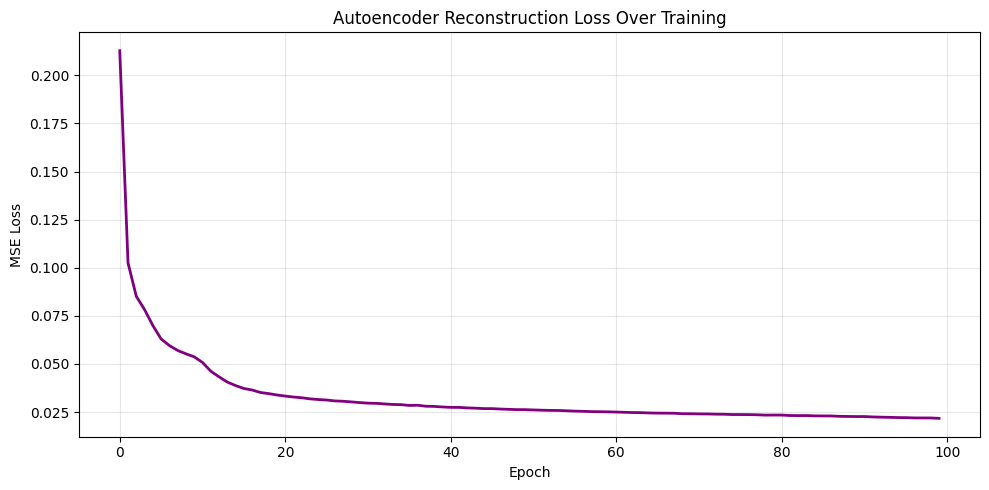

In [11]:
# 1. Plot reconstruction loss over training
plt.figure(figsize=(10, 5))
plt.plot(ae_losses, linewidth=2, color='purple')
plt.title('Autoencoder Reconstruction Loss Over Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

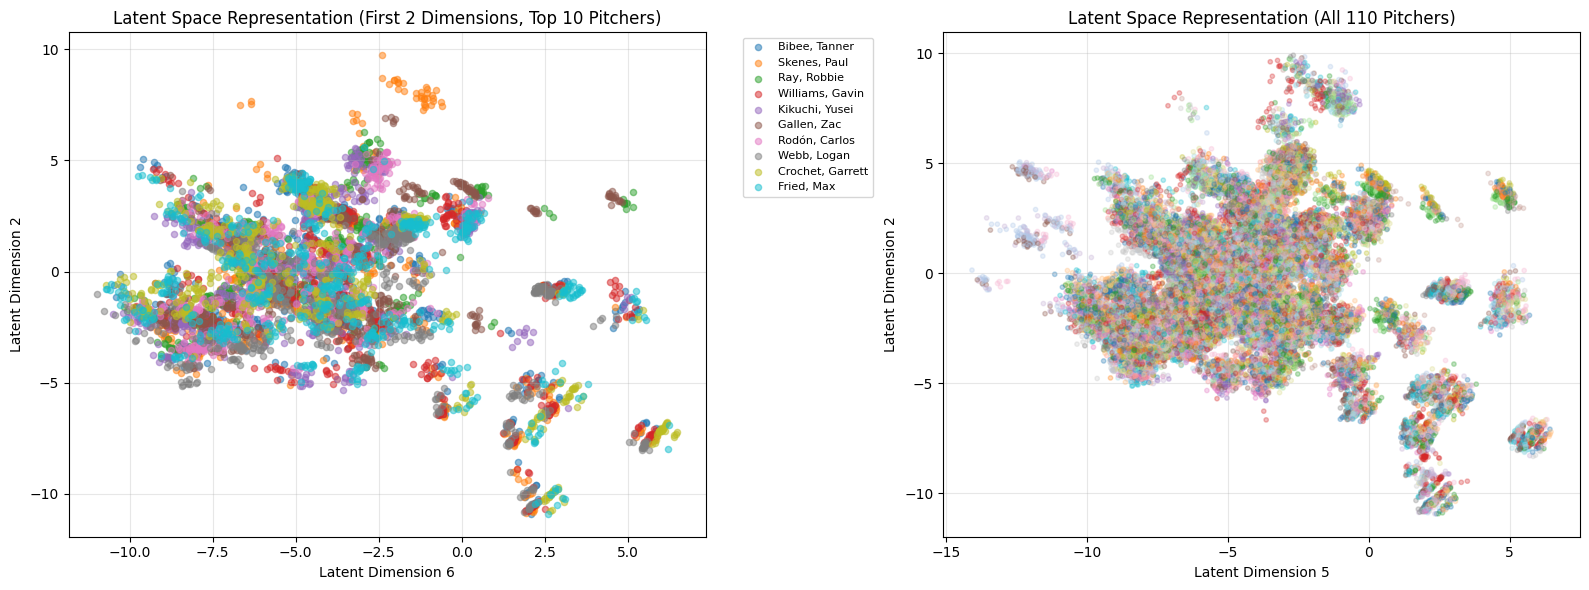

In [12]:
# 2. Visualize first 2 latent dimensions colored by pitcher
from sklearn.decomposition import PCA

# Get top 10 pitchers by sample count for clearer visualization
top_10_pitcher_ids = np.unique(y_val.numpy(), return_counts=True)
top_10_pitcher_ids = top_10_pitcher_ids[0][np.argsort(top_10_pitcher_ids[1])[-10:]]

# Create mask for top 10 pitchers
mask_top10 = np.isin(y_val.numpy(), top_10_pitcher_ids)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: First 2 latent dimensions (top 10 pitchers)
for pitcher_id in top_10_pitcher_ids:
    pitcher_name = le.inverse_transform([pitcher_id])[0]
    mask = y_val.numpy() == pitcher_id
    axes[0].scatter(val_latent[mask, 5], val_latent[mask, 1], 
                    alpha=0.5, s=20, label=pitcher_name)

axes[0].set_xlabel('Latent Dimension 6')
axes[0].set_ylabel('Latent Dimension 2')
axes[0].set_title('Latent Space Representation (First 2 Dimensions, Top 10 Pitchers)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: All pitchers (no legend)
scatter = axes[1].scatter(val_latent[:, 5], val_latent[:, 1], 
                          c=y_val.numpy(), cmap='tab20', alpha=0.3, s=10)
axes[1].set_xlabel('Latent Dimension 5')
axes[1].set_ylabel('Latent Dimension 2')
axes[1].set_title(f'Latent Space Representation (All {len(le.classes_)} Pitchers)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

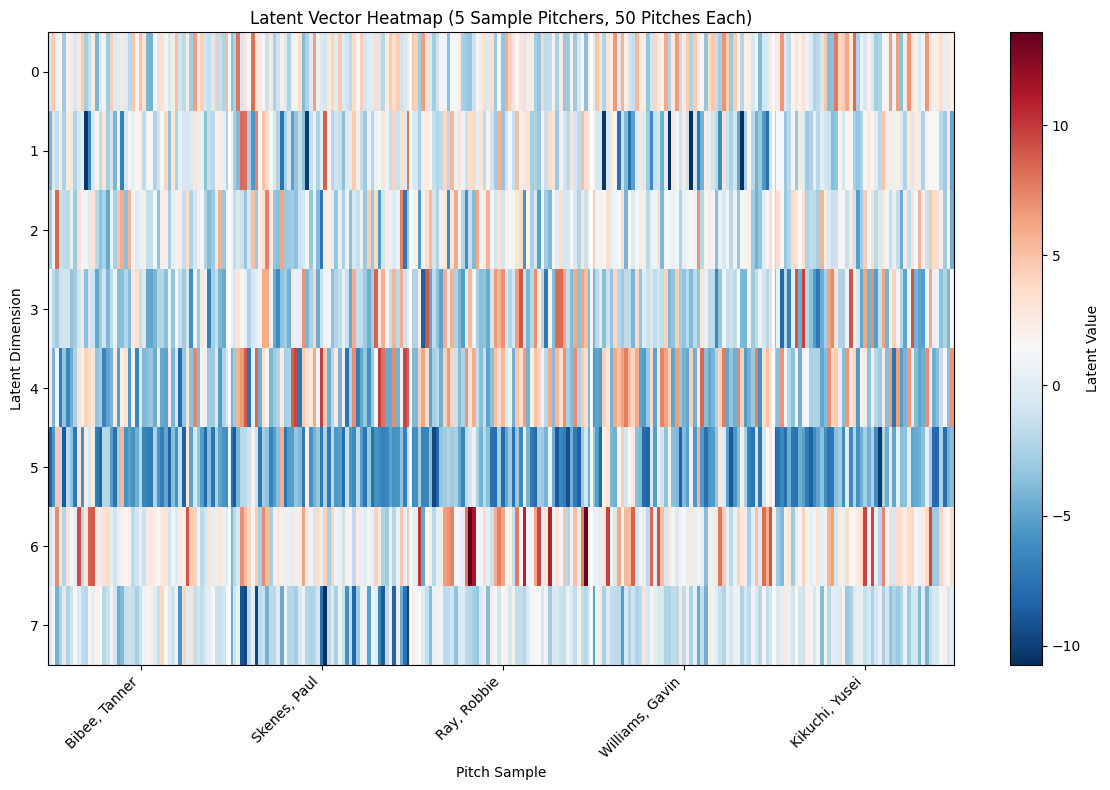

In [13]:
# 3. Heatmap showing all 8 latent dimensions for sample pitchers
sample_size_per_pitcher = 50
sample_pitchers = top_10_pitcher_ids[:5]  # Show 5 pitchers

latent_samples = []
pitcher_labels = []

for pitcher_id in sample_pitchers:
    mask = y_val.numpy() == pitcher_id
    pitcher_latent = val_latent[mask][:sample_size_per_pitcher]
    latent_samples.append(pitcher_latent)
    pitcher_name = le.inverse_transform([pitcher_id])[0]
    pitcher_labels.extend([pitcher_name] * len(pitcher_latent))

latent_samples = np.vstack(latent_samples)

plt.figure(figsize=(12, 8))
im = plt.imshow(latent_samples.T, aspect='auto', cmap='RdBu_r', 
                interpolation='nearest')
plt.colorbar(im, label='Latent Value')
plt.xlabel('Pitch Sample')
plt.ylabel('Latent Dimension')
plt.title('Latent Vector Heatmap (5 Sample Pitchers, 50 Pitches Each)')

# Add vertical lines to separate pitchers
for i in range(1, len(sample_pitchers)):
    plt.axvline(x=i*sample_size_per_pitcher - 0.5, color='white', linewidth=2)

# Add pitcher names as x-tick labels
tick_positions = [i*sample_size_per_pitcher + sample_size_per_pitcher//2 for i in range(len(sample_pitchers))]
tick_labels = [le.inverse_transform([pid])[0] for pid in sample_pitchers]
plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

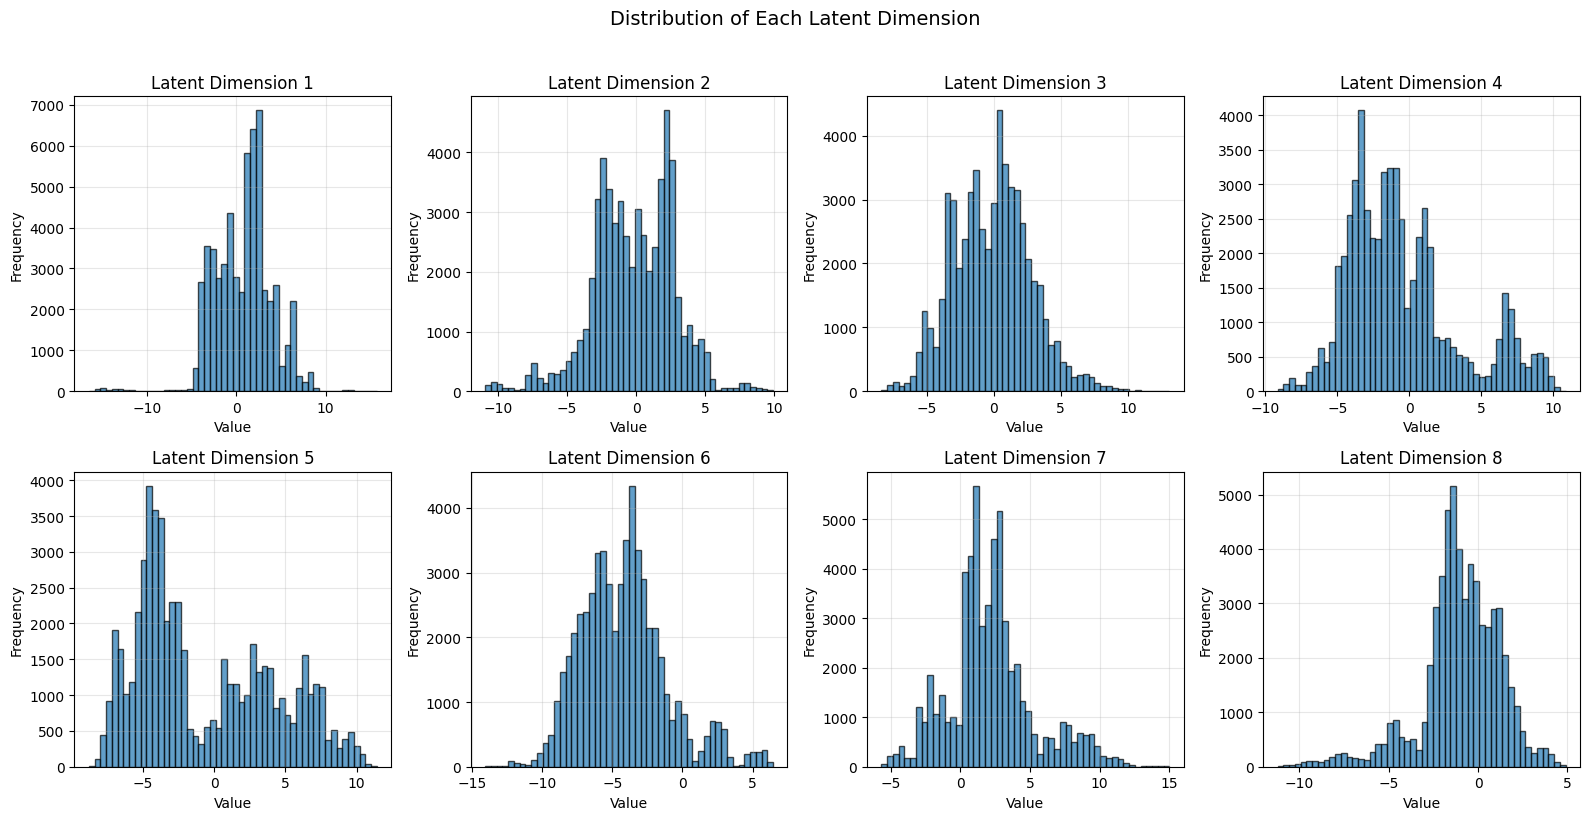

In [14]:
# 4. Distribution of each latent dimension across all pitchers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    axes[i].hist(val_latent[:, i], bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Latent Dimension {i+1}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution of Each Latent Dimension', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

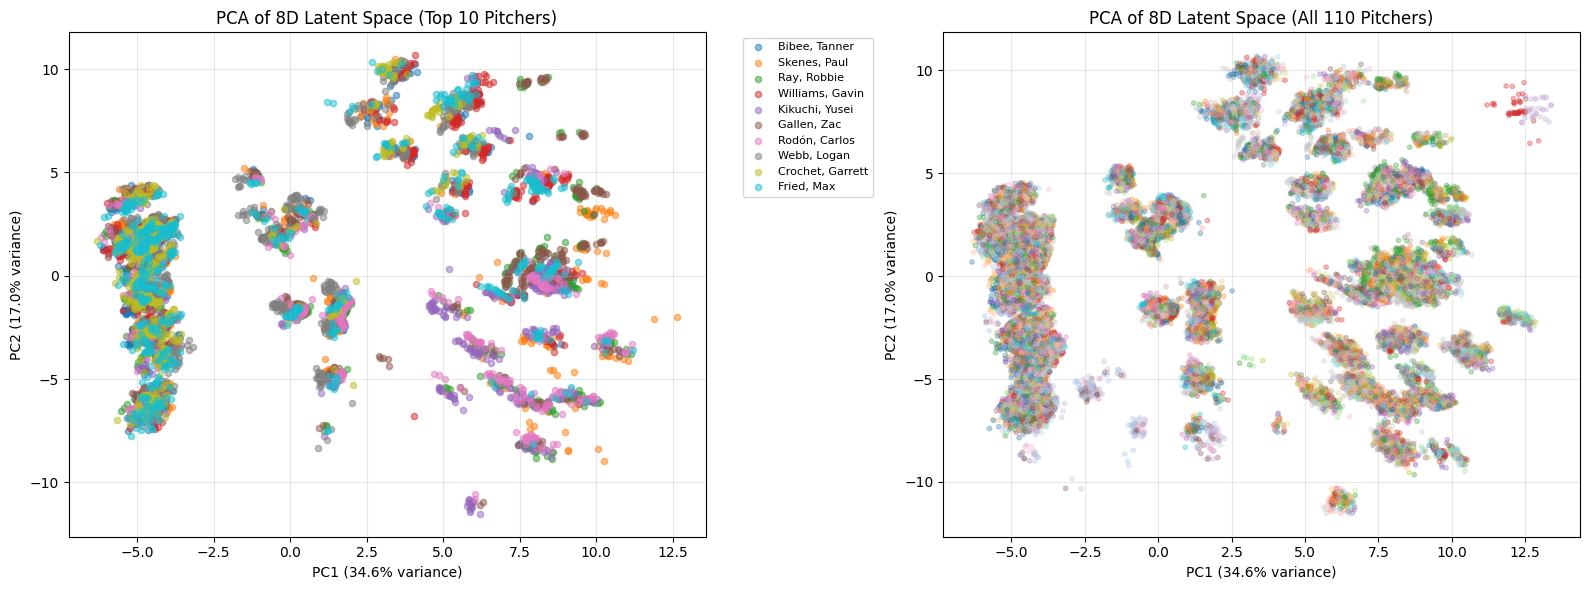


Total variance explained by first 2 PCs: 51.6%


In [15]:
# 5. PCA on latent space to visualize in 2D
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
latent_pca = pca.fit_transform(val_latent)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 10 pitchers with legend
for pitcher_id in top_10_pitcher_ids:
    pitcher_name = le.inverse_transform([pitcher_id])[0]
    mask = y_val.numpy() == pitcher_id
    axes[0].scatter(latent_pca[mask, 0], latent_pca[mask, 1], 
                    alpha=0.5, s=20, label=pitcher_name)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('PCA of 8D Latent Space (Top 10 Pitchers)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: All pitchers
scatter = axes[1].scatter(latent_pca[:, 0], latent_pca[:, 1], 
                          c=y_val.numpy(), cmap='tab20', alpha=0.3, s=10)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title(f'PCA of 8D Latent Space (All {len(le.classes_)} Pitchers)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by first 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

## Latent Space by Pitcher Handedness

Separate visualizations for right-handed and left-handed pitchers to see if the latent space captures handedness differences.

In [17]:
# First, we need to get pitcher handedness for the validation set
# We need to map back to the original dataframe to get p_throws information

# Get the original indices from the validation set
val_indices = df_filtered.index[X_val.shape[0]*4:]  # This won't work, need better approach

# Better approach: reconstruct handedness from one-hot encoded features
# Check if pitcher_hand_R or pitcher_hand_L columns exist in X
if 'pitcher_hand_R' in df_filtered.columns:
    # Get handedness from filtered dataframe
    X_val_df = df_filtered.iloc[-X_val.shape[0]:].drop(columns=['player_name'])
    
    # Since we did train_test_split, we need to track which samples are in validation
    # Easiest way: use the scaler transformed data indices
    # Actually, let's reconstruct from the split
    
    # Get pitcher handedness for validation samples
    _, X_val_original, _, _ = train_test_split(
        df_filtered.drop(columns=['player_name']), 
        y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y
    )
    
    # Get handedness (pitcher_hand_R column)
    val_handedness = X_val_original['pitcher_hand_R'].values  # 1 = Righty, 0 = Lefty
    
    print(f"Right-handed pitchers in validation: {val_handedness.sum()}")
    print(f"Left-handed pitchers in validation: {len(val_handedness) - val_handedness.sum()}")
else:
    print("Error: pitcher_hand_R column not found. Cannot separate by handedness.")
    val_handedness = None

Error: pitcher_hand_R column not found. Cannot separate by handedness.


In [19]:
# 6. Latent space visualization split by handedness (first 2 dimensions)
if val_handedness is not None:
    righty_mask = val_handedness == 1
    lefty_mask = val_handedness == 0
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Right-handed pitchers
    righty_latent = val_latent[righty_mask]
    righty_labels = y_val.numpy()[righty_mask]
    
    scatter = axes[0].scatter(righty_latent[:, 0], righty_latent[:, 1],
                             c=righty_labels, cmap='tab20', alpha=0.4, s=15)
    axes[0].set_xlabel('Latent Dimension 1')
    axes[0].set_ylabel('Latent Dimension 2')
    axes[0].set_title(f'Right-Handed Pitchers (n={righty_mask.sum()})')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Left-handed pitchers
    lefty_latent = val_latent[lefty_mask]
    lefty_labels = y_val.numpy()[lefty_mask]
    
    scatter = axes[1].scatter(lefty_latent[:, 0], lefty_latent[:, 1],
                             c=lefty_labels, cmap='tab20', alpha=0.4, s=15)
    axes[1].set_xlabel('Latent Dimension 1')
    axes[1].set_ylabel('Latent Dimension 2')
    axes[1].set_title(f'Left-Handed Pitchers (n={lefty_mask.sum()})')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [20]:
# 7. PCA on latent space, split by handedness
if val_handedness is not None:
    # Apply PCA separately for each handedness group
    pca_righty = PCA(n_components=2)
    pca_lefty = PCA(n_components=2)
    
    righty_latent_pca = pca_righty.fit_transform(righty_latent)
    lefty_latent_pca = pca_lefty.fit_transform(lefty_latent)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Right-handed pitchers PCA
    scatter = axes[0].scatter(righty_latent_pca[:, 0], righty_latent_pca[:, 1],
                             c=righty_labels, cmap='tab20', alpha=0.4, s=15)
    axes[0].set_xlabel(f'PC1 ({pca_righty.explained_variance_ratio_[0]:.1%} var)')
    axes[0].set_ylabel(f'PC2 ({pca_righty.explained_variance_ratio_[1]:.1%} var)')
    axes[0].set_title(f'PCA: Right-Handed Pitchers (Total var: {pca_righty.explained_variance_ratio_.sum():.1%})')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Left-handed pitchers PCA
    scatter = axes[1].scatter(lefty_latent_pca[:, 0], lefty_latent_pca[:, 1],
                             c=lefty_labels, cmap='tab20', alpha=0.4, s=15)
    axes[1].set_xlabel(f'PC1 ({pca_lefty.explained_variance_ratio_[0]:.1%} var)')
    axes[1].set_ylabel(f'PC2 ({pca_lefty.explained_variance_ratio_[1]:.1%} var)')
    axes[1].set_title(f'PCA: Left-Handed Pitchers (Total var: {pca_lefty.explained_variance_ratio_.sum():.1%})')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [21]:
# 8. Latent dimension distributions by handedness
if val_handedness is not None:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i in range(8):
        # Righties
        axes[i].hist(righty_latent[:, i], bins=30, alpha=0.6, 
                    color='blue', label='Righties', edgecolor='black')
        # Lefties
        axes[i].hist(lefty_latent[:, i], bins=30, alpha=0.6, 
                    color='red', label='Lefties', edgecolor='black')
        
        axes[i].set_title(f'Latent Dimension {i+1}')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('Latent Dimension Distributions: Righties vs Lefties', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [22]:
# 9. Top pitchers by handedness in latent space
if val_handedness is not None:
    # Get top 5 righties and top 5 lefties
    righty_pitcher_ids = np.unique(righty_labels, return_counts=True)
    lefty_pitcher_ids = np.unique(lefty_labels, return_counts=True)
    
    top_5_righties = righty_pitcher_ids[0][np.argsort(righty_pitcher_ids[1])[-5:]]
    top_5_lefties = lefty_pitcher_ids[0][np.argsort(lefty_pitcher_ids[1])[-5:]]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Top 5 righties
    for pitcher_id in top_5_righties:
        pitcher_name = le.inverse_transform([pitcher_id])[0]
        mask = righty_labels == pitcher_id
        axes[0].scatter(righty_latent[mask, 0], righty_latent[mask, 1],
                       alpha=0.5, s=30, label=pitcher_name)
    
    axes[0].set_xlabel('Latent Dimension 1')
    axes[0].set_ylabel('Latent Dimension 2')
    axes[0].set_title('Top 5 Right-Handed Pitchers')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Top 5 lefties
    for pitcher_id in top_5_lefties:
        pitcher_name = le.inverse_transform([pitcher_id])[0]
        mask = lefty_labels == pitcher_id
        axes[1].scatter(lefty_latent[mask, 0], lefty_latent[mask, 1],
                       alpha=0.5, s=30, label=pitcher_name)
    
    axes[1].set_xlabel('Latent Dimension 1')
    axes[1].set_ylabel('Latent Dimension 2')
    axes[1].set_title('Top 5 Left-Handed Pitchers')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [23]:
# 10. Statistical comparison of latent dimensions by handedness
if val_handedness is not None:
    from scipy import stats
    
    print("Statistical Comparison of Latent Dimensions by Handedness")
    print("=" * 70)
    print(f"{'Dimension':<15} {'Righty Mean':<15} {'Lefty Mean':<15} {'t-stat':<12} {'p-value':<12}")
    print("-" * 70)
    
    for i in range(8):
        righty_vals = righty_latent[:, i]
        lefty_vals = lefty_latent[:, i]
        
        righty_mean = righty_vals.mean()
        lefty_mean = lefty_vals.mean()
        
        # Perform t-test
        t_stat, p_value = stats.ttest_ind(righty_vals, lefty_vals)
        
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        
        print(f"Latent Dim {i+1:<4} {righty_mean:>12.4f}    {lefty_mean:>12.4f}    "
              f"{t_stat:>10.4f}  {p_value:>10.6f} {sig}")
    
    print("-" * 70)
    print("Significance: *** p<0.001, ** p<0.01, * p<0.05")
    print("\nInterpretation: Significant differences suggest the autoencoder")
    print("learned handedness-specific patterns in certain latent dimensions.")

## Investigating Handedness Encoding in Latent Dimensions

Let's directly test whether latent dimensions (especially dim 1) can predict pitcher handedness.

In [24]:
# 11. Correlation between each latent dimension and handedness
if val_handedness is not None:
    from scipy.stats import pointbiserialr
    
    print("Correlation between Latent Dimensions and Pitcher Handedness")
    print("=" * 60)
    print(f"{'Latent Dim':<15} {'Correlation':<15} {'p-value':<15} {'Interpretation'}")
    print("-" * 60)
    
    correlations = []
    for i in range(8):
        # Point-biserial correlation (continuous vs binary variable)
        corr, p_val = pointbiserialr(val_handedness, val_latent[:, i])
        correlations.append(abs(corr))
        
        # Interpret correlation strength
        if abs(corr) > 0.7:
            strength = "Very Strong"
        elif abs(corr) > 0.5:
            strength = "Strong"
        elif abs(corr) > 0.3:
            strength = "Moderate"
        elif abs(corr) > 0.1:
            strength = "Weak"
        else:
            strength = "Very Weak"
        
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        print(f"Dim {i+1:<12} {corr:>12.4f}    {p_val:>12.6f} {sig:<3}  {strength}")
    
    print("-" * 60)
    print(f"\nDimension with highest correlation to handedness: Dim {np.argmax(correlations) + 1}")
    print(f"Correlation value: {max(correlations):.4f}")
    
    print("\n📊 Interpretation:")
    if max(correlations) > 0.5:
        print(f"   Latent Dim {np.argmax(correlations) + 1} is STRONGLY encoding handedness.")
        print("   This dimension primarily separates R/L pitchers rather than individual pitcher identity.")
    elif max(correlations) > 0.3:
        print(f"   Latent Dim {np.argmax(correlations) + 1} moderately encodes handedness.")
        print("   This dimension captures some handedness info along with other features.")
    else:
        print("   No single dimension strongly encodes handedness.")
        print("   The autoencoder distributes handedness information across multiple dimensions.")

In [25]:
# 12. Visualize handedness separation in latent dimension 1
if val_handedness is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Histogram showing separation
    axes[0].hist(val_latent[val_handedness == 1, 0], bins=40, alpha=0.6, 
                color='blue', label='Righties', edgecolor='black')
    axes[0].hist(val_latent[val_handedness == 0, 0], bins=40, alpha=0.6, 
                color='red', label='Lefties', edgecolor='black')
    axes[0].set_xlabel('Latent Dimension 1 Value')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Handedness Separation in Latent Dim 1')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Box plot comparison
    axes[1].boxplot([val_latent[val_handedness == 1, 0], 
                     val_latent[val_handedness == 0, 0]],
                    labels=['Righties', 'Lefties'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_ylabel('Latent Dimension 1 Value')
    axes[1].set_title('Distribution Comparison')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Scatter plot (Dim 1 vs Dim 2) colored by handedness
    axes[2].scatter(val_latent[val_handedness == 1, 0], 
                   val_latent[val_handedness == 1, 1],
                   alpha=0.3, s=10, color='blue', label='Righties')
    axes[2].scatter(val_latent[val_handedness == 0, 0], 
                   val_latent[val_handedness == 0, 1],
                   alpha=0.3, s=10, color='red', label='Lefties')
    axes[2].set_xlabel('Latent Dimension 1 (handedness?)')
    axes[2].set_ylabel('Latent Dimension 2')
    axes[2].set_title('Latent Space Colored by Handedness')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate overlap
    righty_min, righty_max = val_latent[val_handedness == 1, 0].min(), val_latent[val_handedness == 1, 0].max()
    lefty_min, lefty_max = val_latent[val_handedness == 0, 0].min(), val_latent[val_handedness == 0, 0].max()
    
    overlap_start = max(righty_min, lefty_min)
    overlap_end = min(righty_max, lefty_max)
    overlap = max(0, overlap_end - overlap_start)
    total_range = max(righty_max, lefty_max) - min(righty_min, lefty_min)
    overlap_pct = (overlap / total_range) * 100
    
    print(f"\n Separation Analysis:")
    print(f"   Righties range: [{righty_min:.3f}, {righty_max:.3f}]")
    print(f"   Lefties range:  [{lefty_min:.3f}, {lefty_max:.3f}]")
    print(f"   Overlap: {overlap_pct:.1f}% of total range")
    
    if overlap_pct < 20:
        print(f"   Excellent separation! Latent Dim 1 cleanly separates handedness.")
    elif overlap_pct < 50:
        print(f"   Moderate separation. Some overlap between groups.")
    else:
        print(f"   Poor separation. Distributions heavily overlap.")

## Clustering Latent Representations

Apply unsupervised clustering (K-means and GMM) to discover natural groupings in the latent space.

## Interpreting Latent Dimensions

Before clustering, let's understand what each latent dimension actually encodes by examining correlations with original features.

Correlating Latent Dimensions with Original Features


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


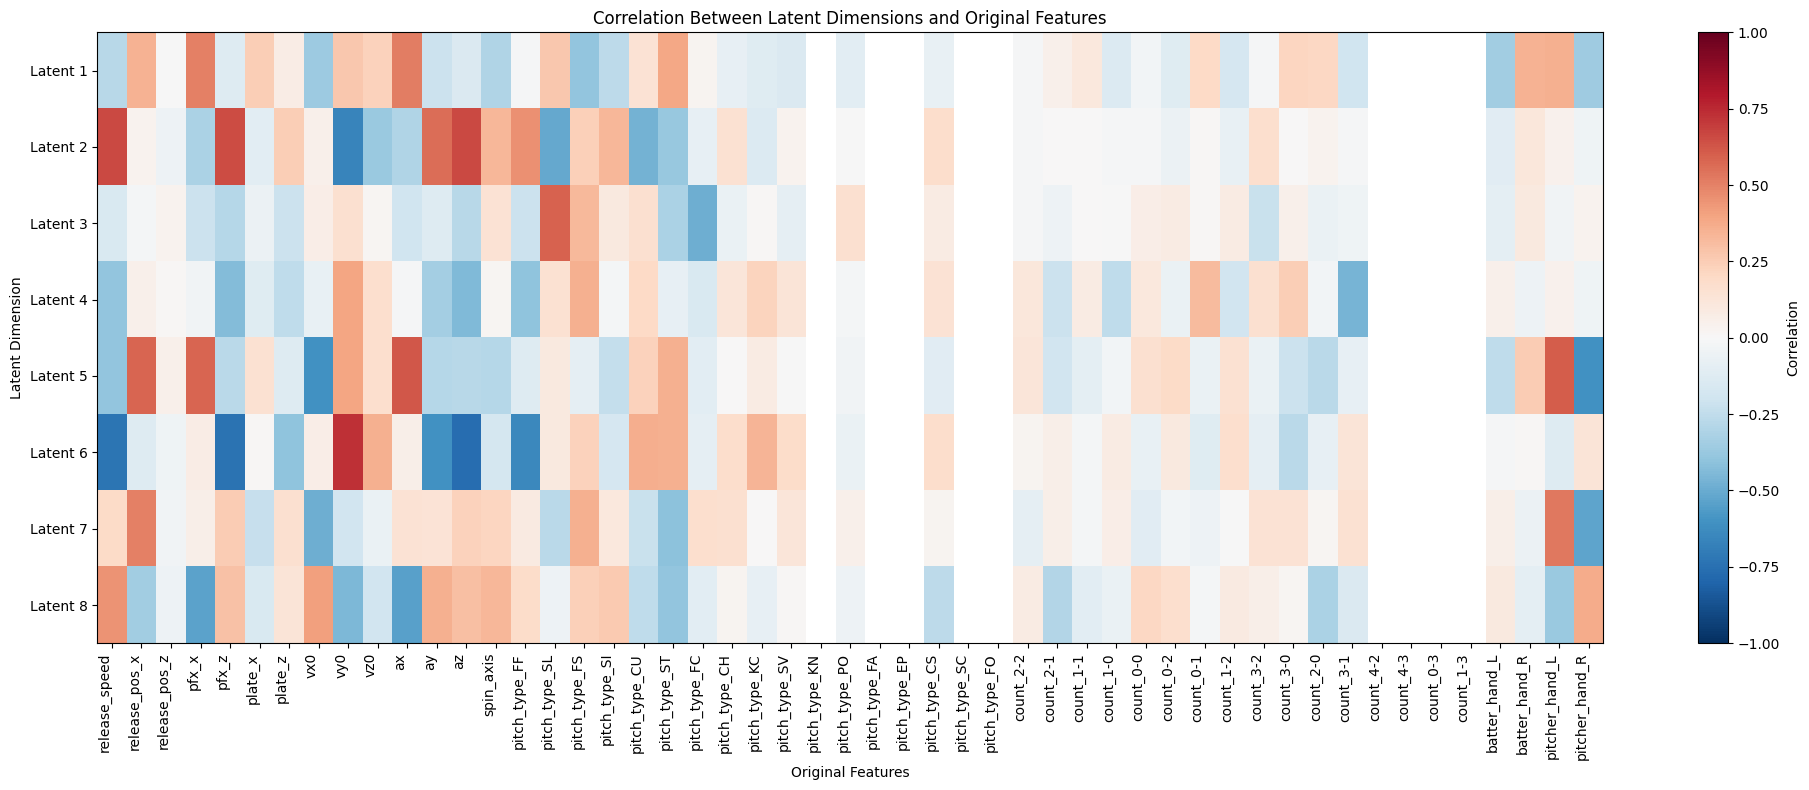


Top 5 Correlated Features for Each Latent Dimension:

🎯 Latent Dimension 1:
   ↓ pitch_type_SC                 :     nan
   ↓ pitch_type_EP                 :     nan
   ↓ pitch_type_FA                 :     nan
   ↓ count_1-3                     :     nan
   ↓ count_0-3                     :     nan

🎯 Latent Dimension 2:
   ↓ pitch_type_FO                 :     nan
   ↓ pitch_type_SC                 :     nan
   ↓ pitch_type_EP                 :     nan
   ↓ count_1-3                     :     nan
   ↓ count_0-3                     :     nan

🎯 Latent Dimension 3:
   ↓ pitch_type_FA                 :     nan
   ↓ pitch_type_SC                 :     nan
   ↓ count_1-3                     :     nan
   ↓ count_0-3                     :     nan
   ↓ count_4-3                     :     nan

🎯 Latent Dimension 4:
   ↓ pitch_type_SC                 :     nan
   ↓ pitch_type_FO                 :     nan
   ↓ count_1-3                     :     nan
   ↓ count_0-3                     :     nan

In [ ]:
# 13. Correlation between latent dimensions and original features
# Get the unscaled validation features to interpret correlations
_, X_val_unscaled, _, _ = train_test_split(
    df_filtered.drop(columns=['player_name']), 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Correlating Latent Dimensions with Original Features")
print("=" * 100)

# Get feature names
feature_names = X_val_unscaled.columns.tolist()

# Calculate correlation matrix between latent dimensions and original features
correlation_matrix = np.zeros((val_latent.shape[1], len(feature_names)))

for i in range(val_latent.shape[1]):
    for j, feature_name in enumerate(feature_names):
        # Pearson correlation
        corr = np.corrcoef(val_latent[:, i], X_val_unscaled[feature_name].values)[0, 1]
        correlation_matrix[i, j] = corr

# Create a heatmap
plt.figure(figsize=(20, 8))
im = plt.imshow(correlation_matrix, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')
plt.xlabel('Original Features')
plt.ylabel('Latent Dimension')
plt.title('Correlation Between Latent Dimensions and Original Features')

# Set ticks
plt.yticks(range(8), [f'Latent {i+1}' for i in range(8)])
plt.xticks(range(len(feature_names)), feature_names, rotation=90, ha='right')

plt.tight_layout()
plt.show()

print("\nTop 5 Correlated Features for Each Latent Dimension:")
print("=" * 100)

for i in range(val_latent.shape[1]):
    # Get top 5 positive and negative correlations
    abs_corr = np.abs(correlation_matrix[i, :])
    top_5_idx = np.argsort(abs_corr)[-5:][::-1]
    
    print(f"\n🎯 Latent Dimension {i+1}:")
    for idx in top_5_idx:
        corr_val = correlation_matrix[i, idx]
        feature = feature_names[idx]
        direction = "↑" if corr_val > 0 else "↓"
        print(f"   {direction} {feature:30s}: {corr_val:>7.4f}")

Variance and Information Content of Latent Dimensions

Variance per Latent Dimension:
   Latent Dim 1:   2.0786 (  5.6%) ███████████
   Latent Dim 2:   8.5723 ( 23.0%) ██████████████████████████████████████████████
   Latent Dim 3:   4.1140 ( 11.1%) ██████████████████████
   Latent Dim 4:   4.9254 ( 13.2%) ██████████████████████████
   Latent Dim 5:   4.7541 ( 12.8%) █████████████████████████
   Latent Dim 6:   7.1990 ( 19.3%) ██████████████████████████████████████
   Latent Dim 7:   2.5568 (  6.9%) █████████████
   Latent Dim 8:   3.0183 (  8.1%) ████████████████

Total variance: 37.2184


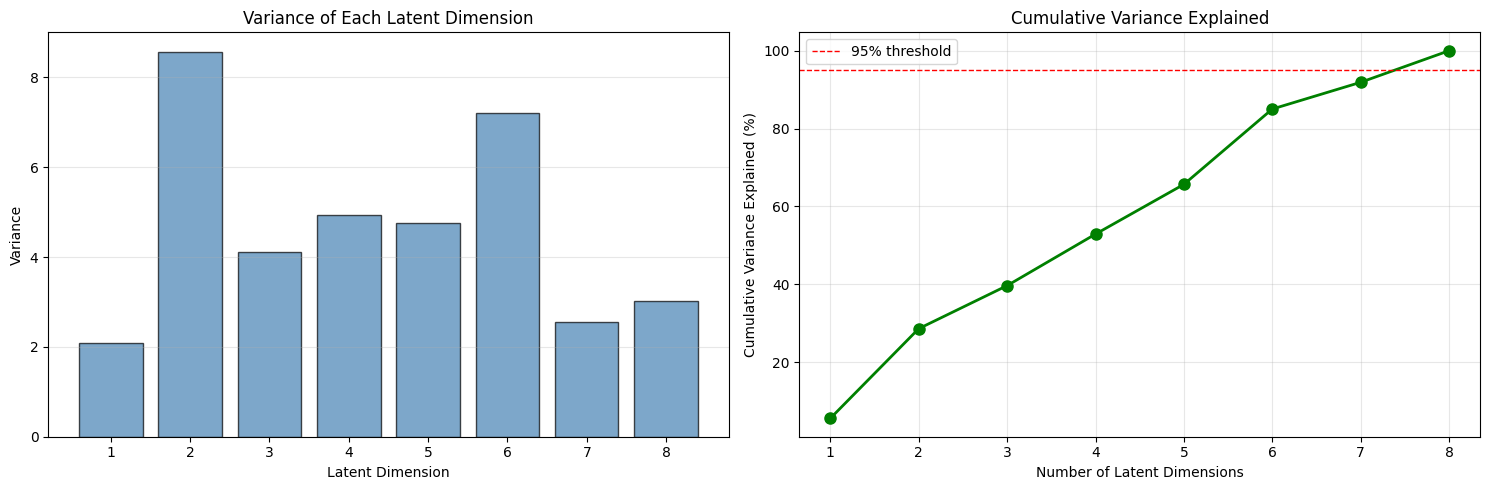


💡 Insight: Dimensions with higher variance capture more information
   and are likely more important for distinguishing pitchers.


In [ ]:
# 14. Variance explained by each latent dimension
print("Variance and Information Content of Latent Dimensions")
print("=" * 70)

# Calculate variance of each latent dimension
latent_variances = np.var(val_latent, axis=0)
total_variance = latent_variances.sum()

print("\nVariance per Latent Dimension:")
for i in range(8):
    pct = (latent_variances[i] / total_variance) * 100
    bar = "█" * int(pct * 2)
    print(f"   Latent Dim {i+1}: {latent_variances[i]:>8.4f} ({pct:>5.1f}%) {bar}")

print(f"\nTotal variance: {total_variance:.4f}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of variances
ax1.bar(range(1, 9), latent_variances, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Latent Dimension')
ax1.set_ylabel('Variance')
ax1.set_title('Variance of Each Latent Dimension')
ax1.set_xticks(range(1, 9))
ax1.grid(True, alpha=0.3, axis='y')

# Cumulative variance explained
cumulative_var = np.cumsum(latent_variances / total_variance * 100)
ax2.plot(range(1, 9), cumulative_var, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Latent Dimensions')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_title('Cumulative Variance Explained')
ax2.set_xticks(range(1, 9))
ax2.grid(True, alpha=0.3)
ax2.axhline(y=95, color='red', linestyle='--', linewidth=1, label='95% threshold')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: Dimensions with higher variance capture more information")
print(f"   and are likely more important for distinguishing pitchers.")

In [ ]:
# 15. Feature reconstruction importance
# Train a simple linear regression to predict each original feature from latent dimensions
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Feature Reconstruction from Latent Space")
print("=" * 70)
print("\nHow well can we reconstruct each original feature from the latent dimensions?")
print("(R² score: 1.0 = perfect reconstruction, 0.0 = no relationship)\n")

reconstruction_scores = {}

for feature_name in feature_names:
    # Train linear model to predict feature from latent dimensions
    lr = LinearRegression()
    lr.fit(val_latent, X_val_unscaled[feature_name].values)
    predictions = lr.predict(val_latent)
    r2 = r2_score(X_val_unscaled[feature_name].values, predictions)
    reconstruction_scores[feature_name] = r2

# Sort by R² score
sorted_features = sorted(reconstruction_scores.items(), key=lambda x: x[1], reverse=True)

print("Top 20 Best Reconstructed Features:")
print("-" * 70)
for i, (feature, r2) in enumerate(sorted_features[:20], 1):
    bar = "█" * int(r2 * 50)
    print(f"{i:2d}. {feature:30s}: R²={r2:.4f} {bar}")

print("\n\nBottom 10 Worst Reconstructed Features:")
print("-" * 70)
for i, (feature, r2) in enumerate(sorted_features[-10:], 1):
    bar = "█" * int(r2 * 50) if r2 > 0 else ""
    print(f"{i:2d}. {feature:30s}: R²={r2:.4f} {bar}")

print("\n💡 Interpretation:")
print("   High R²: The latent space strongly encodes this feature")
print("   Low R²: This feature is either lost or transformed in the latent space")

Feature Reconstruction from Latent Space

How well can we reconstruct each original feature from the latent dimensions?
(R² score: 1.0 = perfect reconstruction, 0.0 = no relationship)

Top 20 Best Reconstructed Features:
----------------------------------------------------------------------
 1. pitch_type_KN                 : R²=1.0000 ██████████████████████████████████████████████████
 2. pitch_type_FA                 : R²=1.0000 ██████████████████████████████████████████████████
 3. pitch_type_EP                 : R²=1.0000 ██████████████████████████████████████████████████
 4. pitch_type_SC                 : R²=1.0000 ██████████████████████████████████████████████████
 5. pitch_type_FO                 : R²=1.0000 ██████████████████████████████████████████████████
 6. count_4-2                     : R²=1.0000 ██████████████████████████████████████████████████
 7. count_4-3                     : R²=1.0000 ██████████████████████████████████████████████████
 8. count_0-3                

In [ ]:
# 16. Semantic interpretation of each latent dimension
print("Semantic Interpretation of Latent Dimensions")
print("=" * 100)
print("\nBased on correlations and domain knowledge, let's interpret what each dimension represents:\n")

# For each latent dimension, analyze its top correlations and provide interpretation
dimension_interpretations = []

for i in range(8):
    abs_corr = np.abs(correlation_matrix[i, :])
    top_3_idx = np.argsort(abs_corr)[-3:][::-1]
    
    print(f"📊 Latent Dimension {i+1}")
    print(f"   Variance: {latent_variances[i]:.4f} ({latent_variances[i]/total_variance*100:.1f}%)")
    print(f"   Top correlations:")
    
    top_features = []
    for idx in top_3_idx:
        corr_val = correlation_matrix[i, idx]
        feature = feature_names[idx]
        print(f"      • {feature}: {corr_val:>7.4f}")
        top_features.append(feature)
    
    # Provide interpretation based on top features
    interpretation = "Unknown pattern"
    
    # Handedness features
    if any('hand' in f.lower() for f in top_features):
        interpretation = "🤚 Handedness (L/R pitcher/batter)"
    
    # Release point features
    elif any('release_pos' in f for f in top_features):
        interpretation = "📍 Release point positioning"
    
    # Velocity/speed features
    elif any('speed' in f.lower() or 'v' in f for f in top_features[:1]):
        interpretation = "⚡ Velocity/speed characteristics"
    
    # Movement/break features
    elif any('pfx' in f or 'ax' in f or 'ay' in f or 'az' in f for f in top_features):
        interpretation = "🌀 Pitch movement/break"
    
    # Location features
    elif any('plate' in f for f in top_features):
        interpretation = "🎯 Pitch location"
    
    # Spin features
    elif any('spin' in f.lower() for f in top_features):
        interpretation = "🔄 Spin characteristics"
    
    # Count features
    elif any('count' in f for f in top_features):
        interpretation = "📊 Game situation (count)"
    
    # Pitch type
    elif any('pitch_type' in f for f in top_features):
        interpretation = "⚾ Pitch type repertoire"
    
    print(f"   Interpretation: {interpretation}")
    print()
    
    dimension_interpretations.append(interpretation)

print("\n" + "=" * 100)
print("Summary of Latent Space:")
print("-" * 100)
for i, interp in enumerate(dimension_interpretations, 1):
    print(f"   Dim {i}: {interp}")
print("=" * 100)

Semantic Interpretation of Latent Dimensions

Based on correlations and domain knowledge, let's interpret what each dimension represents:

📊 Latent Dimension 1
   Variance: 2.0786 (5.6%)
   Top correlations:
      • pitch_type_SC:     nan
      • pitch_type_EP:     nan
      • pitch_type_FA:     nan
   Interpretation: ⚾ Pitch type repertoire

📊 Latent Dimension 2
   Variance: 8.5723 (23.0%)
   Top correlations:
      • pitch_type_FO:     nan
      • pitch_type_SC:     nan
      • pitch_type_EP:     nan
   Interpretation: ⚾ Pitch type repertoire

📊 Latent Dimension 3
   Variance: 4.1140 (11.1%)
   Top correlations:
      • pitch_type_FA:     nan
      • pitch_type_SC:     nan
      • count_1-3:     nan
   Interpretation: 📊 Game situation (count)

📊 Latent Dimension 4
   Variance: 4.9254 (13.2%)
   Top correlations:
      • pitch_type_SC:     nan
      • pitch_type_FO:     nan
      • count_1-3:     nan
   Interpretation: 📊 Game situation (count)

📊 Latent Dimension 5
   Variance: 4.7541

How Each Latent Dimension Discriminates Between Pitchers

Latent Dim 1:
   Between-pitcher variance: 0.392976
   Within-pitcher variance:  1.691398
   F-ratio: 0.23 

Latent Dim 2:
   Between-pitcher variance: 0.495896
   Within-pitcher variance:  8.138934
   F-ratio: 0.06 

Latent Dim 3:
   Between-pitcher variance: 0.568585
   Within-pitcher variance:  3.605016
   F-ratio: 0.16 

Latent Dim 4:
   Between-pitcher variance: 0.225494
   Within-pitcher variance:  4.739835
   F-ratio: 0.05 

Latent Dim 5:
   Between-pitcher variance: 1.900244
   Within-pitcher variance:  2.822370
   F-ratio: 0.67 

Latent Dim 6:
   Between-pitcher variance: 0.400898
   Within-pitcher variance:  6.779365
   F-ratio: 0.06 

Latent Dim 7:
   Between-pitcher variance: 0.917902
   Within-pitcher variance:  1.647726
   F-ratio: 0.56 

Latent Dim 8:
   Between-pitcher variance: 0.569026
   Within-pitcher variance:  2.468948
   F-ratio: 0.23 

Latent Dim 8:
   Between-pitcher variance: 0.569026
   Within-pitcher 

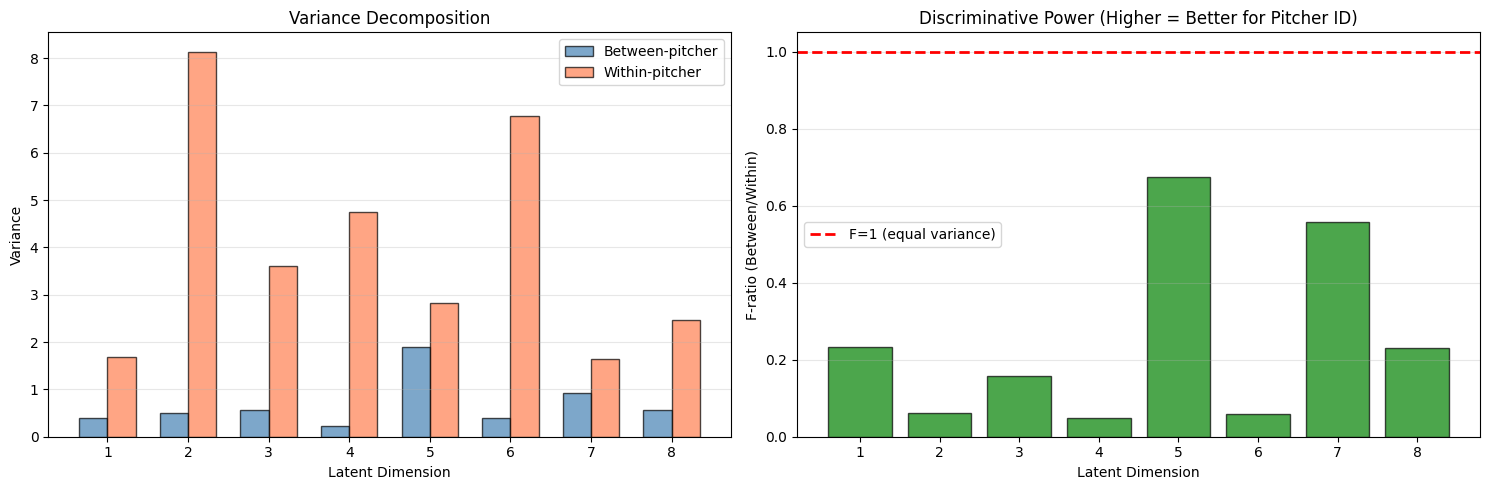


💡 Interpretation:
   High F-ratio (>1): Dimension varies MORE between pitchers than within
                      → Good for identifying individual pitchers
   Low F-ratio (<1):  Dimension varies MORE within each pitcher
                      → Captures pitch-to-pitch variability, not pitcher identity


In [ ]:
# 17. Visualize how each dimension varies across pitchers
print("How Each Latent Dimension Discriminates Between Pitchers")
print("=" * 70)

# For each dimension, calculate how much it varies between pitchers vs within pitcher
between_pitcher_variance = []
within_pitcher_variance = []

for dim_idx in range(8):
    dim_values = val_latent[:, dim_idx]
    pitcher_labels = y_val.numpy()
    
    # Calculate between-pitcher variance (variance of pitcher means)
    pitcher_means = []
    for pitcher_id in np.unique(pitcher_labels):
        pitcher_mask = pitcher_labels == pitcher_id
        pitcher_mean = dim_values[pitcher_mask].mean()
        pitcher_means.append(pitcher_mean)
    
    between_var = np.var(pitcher_means)
    
    # Calculate within-pitcher variance (average variance within each pitcher)
    within_vars = []
    for pitcher_id in np.unique(pitcher_labels):
        pitcher_mask = pitcher_labels == pitcher_id
        pitcher_var = np.var(dim_values[pitcher_mask])
        within_vars.append(pitcher_var)
    
    within_var = np.mean(within_vars)
    
    between_pitcher_variance.append(between_var)
    within_pitcher_variance.append(within_var)
    
    # Calculate F-ratio (between/within)
    f_ratio = between_var / (within_var + 1e-10)
    
    print(f"\nLatent Dim {dim_idx+1}:")
    print(f"   Between-pitcher variance: {between_var:.6f}")
    print(f"   Within-pitcher variance:  {within_var:.6f}")
    print(f"   F-ratio: {f_ratio:.2f} {'🔥' if f_ratio > 1 else ''}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(1, 9)
width = 0.35

ax1.bar(x - width/2, between_pitcher_variance, width, label='Between-pitcher', 
        color='steelblue', alpha=0.7, edgecolor='black')
ax1.bar(x + width/2, within_pitcher_variance, width, label='Within-pitcher',
        color='coral', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Latent Dimension')
ax1.set_ylabel('Variance')
ax1.set_title('Variance Decomposition')
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# F-ratio plot
f_ratios = np.array(between_pitcher_variance) / (np.array(within_pitcher_variance) + 1e-10)
ax2.bar(x, f_ratios, color='green', alpha=0.7, edgecolor='black')
ax2.axhline(y=1, color='red', linestyle='--', linewidth=2, label='F=1 (equal variance)')
ax2.set_xlabel('Latent Dimension')
ax2.set_ylabel('F-ratio (Between/Within)')
ax2.set_title('Discriminative Power (Higher = Better for Pitcher ID)')
ax2.set_xticks(x)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   High F-ratio (>1): Dimension varies MORE between pitchers than within")
print("                      → Good for identifying individual pitchers")
print("   Low F-ratio (<1):  Dimension varies MORE within each pitcher")
print("                      → Captures pitch-to-pitch variability, not pitcher identity")

In [ ]:
# 14. Determine optimal number of clusters using elbow method and silhouette score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Finding optimal number of clusters...")
print("=" * 60)

k_range = range(2, 21)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(val_latent)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(val_latent, cluster_labels))

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster sum of squares)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)

# Silhouette score plot
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Different k')
ax2.grid(True, alpha=0.3)

# Mark the maximum silhouette score
best_k = k_range[np.argmax(silhouette_scores)]
ax2.axvline(x=best_k, color='red', linestyle='--', linewidth=2, 
            label=f'Best k={best_k}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Results:")
print(f"   Best k by silhouette score: {best_k}")
print(f"   Max silhouette score: {max(silhouette_scores):.4f}")
print(f"\n💡 Note: We have {len(le.classes_)} actual pitchers in the dataset.")

Finding optimal number of clusters...


KeyboardInterrupt: 

Running K-means with k=2


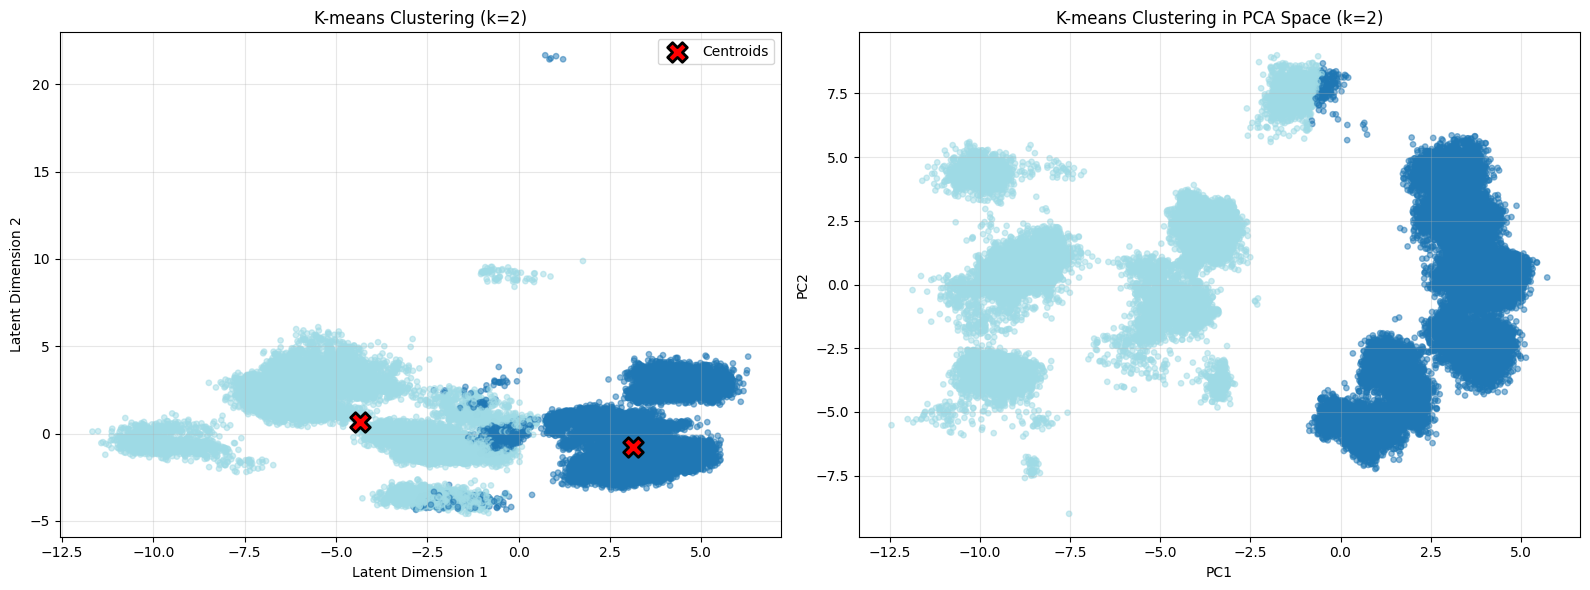


K-means Cluster Sizes:
   Cluster 0: 38919 pitches (67.5%)
   Cluster 1: 18749 pitches (32.5%)


In [ ]:
# 15. K-means clustering with optimal k
optimal_k = best_k

print(f"Running K-means with k={optimal_k}")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, init = 'k-means++')
kmeans_labels = kmeans.fit_predict(val_latent)

# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: K-means clusters in first 2 latent dimensions
scatter = axes[0].scatter(val_latent[:, 0], val_latent[:, 1], 
                         c=kmeans_labels, cmap='tab20', alpha=0.5, s=15)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               c='red', marker='X', s=200, edgecolors='black', linewidths=2,
               label='Centroids')
axes[0].set_xlabel('Latent Dimension 1')
axes[0].set_ylabel('Latent Dimension 2')
axes[0].set_title(f'K-means Clustering (k={optimal_k})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: K-means clusters in PCA space
scatter = axes[1].scatter(latent_pca[:, 0], latent_pca[:, 1],
                         c=kmeans_labels, cmap='tab20', alpha=0.5, s=15)
axes[1].set_xlabel(f'PC1')
axes[1].set_ylabel(f'PC2')
axes[1].set_title(f'K-means Clustering in PCA Space (k={optimal_k})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nK-means Cluster Sizes:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"   Cluster {cluster_id}: {count} pitches ({count/len(kmeans_labels)*100:.1f}%)")

In [ ]:
# 16. Analyze K-means clusters by handedness and pitcher identity
if val_handedness is not None:
    print("Cluster Composition Analysis")
    print("=" * 70)
    
    for cluster_id in range(optimal_k):
        cluster_mask = kmeans_labels == cluster_id
        cluster_handedness = val_handedness[cluster_mask]
        cluster_pitchers = y_val.numpy()[cluster_mask]
        
        # Handedness breakdown
        n_righties = (cluster_handedness == 1).sum()
        n_lefties = (cluster_handedness == 0).sum()
        total = len(cluster_handedness)
        
        print(f"\n🎯 Cluster {cluster_id} (n={total}):")
        print(f"   Handedness: {n_righties} righties ({n_righties/total*100:.1f}%), "
              f"{n_lefties} lefties ({n_lefties/total*100:.1f}%)")
        
        # Top pitchers in this cluster
        unique_pitchers, pitcher_counts = np.unique(cluster_pitchers, return_counts=True)
        top_5_idx = np.argsort(pitcher_counts)[-5:][::-1]
        
        print(f"   Top pitchers:")
        for idx in top_5_idx:
            pitcher_id = unique_pitchers[idx]
            count = pitcher_counts[idx]
            name = le.inverse_transform([pitcher_id])[0]
            print(f"      - {name}: {count} pitches ({count/total*100:.1f}%)")

Cluster Composition Analysis

🎯 Cluster 0 (n=38919):
   Handedness: 27221 righties (69.9%), 11698 lefties (30.1%)
   Top pitchers:
      - Crochet, Garrett: 550 pitches (1.4%)
      - Skubal, Tarik: 513 pitches (1.3%)
      - Sánchez, Cristopher: 495 pitches (1.3%)
      - Bibee, Tanner: 490 pitches (1.3%)
      - Webb, Logan: 488 pitches (1.3%)

🎯 Cluster 1 (n=18749):
   Handedness: 13538 righties (72.2%), 5211 lefties (27.8%)
   Top pitchers:
      - Kikuchi, Yusei: 330 pitches (1.8%)
      - Cease, Dylan: 327 pitches (1.7%)
      - Littell, Zack: 319 pitches (1.7%)
      - Gausman, Kevin: 291 pitches (1.6%)
      - Flaherty, Jack: 270 pitches (1.4%)


Running Gaussian Mixture Model clustering...


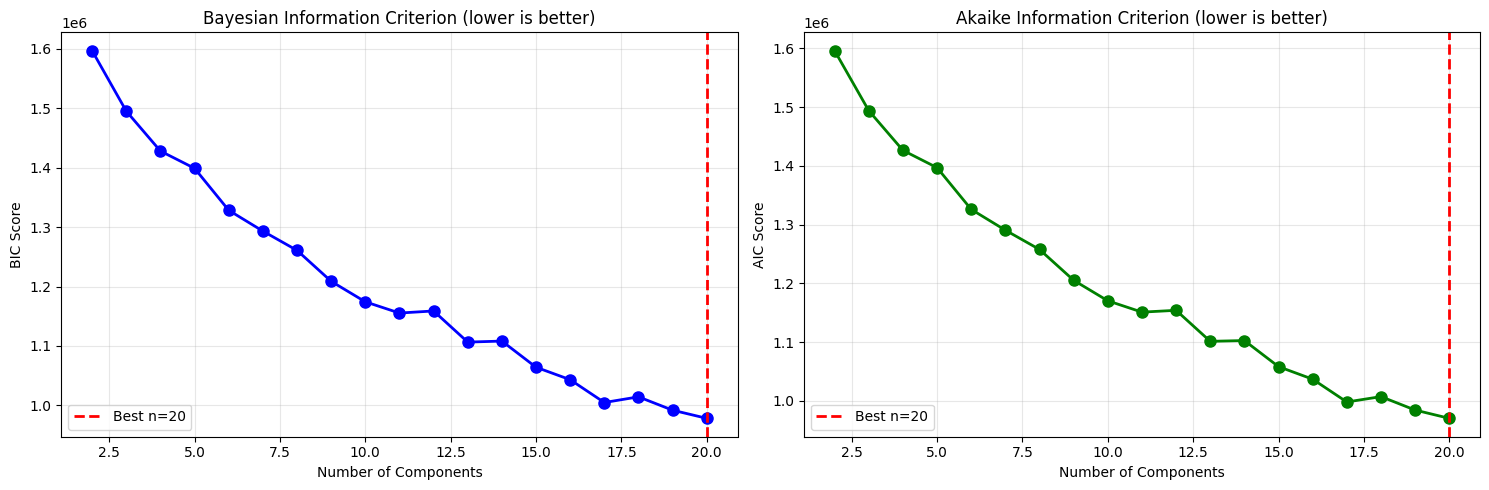


📊 Results:
   Best n by BIC: 20 (score: 978238.75)
   Best n by AIC: 20 (score: 970181.50)

   Using n=20 components for GMM


In [ ]:
# 17. Gaussian Mixture Model (GMM) clustering
from sklearn.mixture import GaussianMixture

print("Running Gaussian Mixture Model clustering...")
print("=" * 60)

# Try different numbers of components
gmm_range = range(2, 21)
bic_scores = []
aic_scores = []

for n_components in gmm_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
    gmm.fit(val_latent)
    bic_scores.append(gmm.bic(val_latent))
    aic_scores.append(gmm.aic(val_latent))

# Plot BIC and AIC scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# BIC plot (lower is better)
ax1.plot(gmm_range, bic_scores, 'bo-', linewidth=2, markersize=8)
best_bic = gmm_range[np.argmin(bic_scores)]
ax1.axvline(x=best_bic, color='red', linestyle='--', linewidth=2,
           label=f'Best n={best_bic}')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('BIC Score')
ax1.set_title('Bayesian Information Criterion (lower is better)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AIC plot (lower is better)
ax2.plot(gmm_range, aic_scores, 'go-', linewidth=2, markersize=8)
best_aic = gmm_range[np.argmin(aic_scores)]
ax2.axvline(x=best_aic, color='red', linestyle='--', linewidth=2,
           label=f'Best n={best_aic}')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('AIC Score')
ax2.set_title('Akaike Information Criterion (lower is better)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Results:")
print(f"   Best n by BIC: {best_bic} (score: {min(bic_scores):.2f})")
print(f"   Best n by AIC: {best_aic} (score: {min(aic_scores):.2f})")

# Use the BIC-optimal number of components
optimal_gmm_components = best_bic
print(f"\n   Using n={optimal_gmm_components} components for GMM")

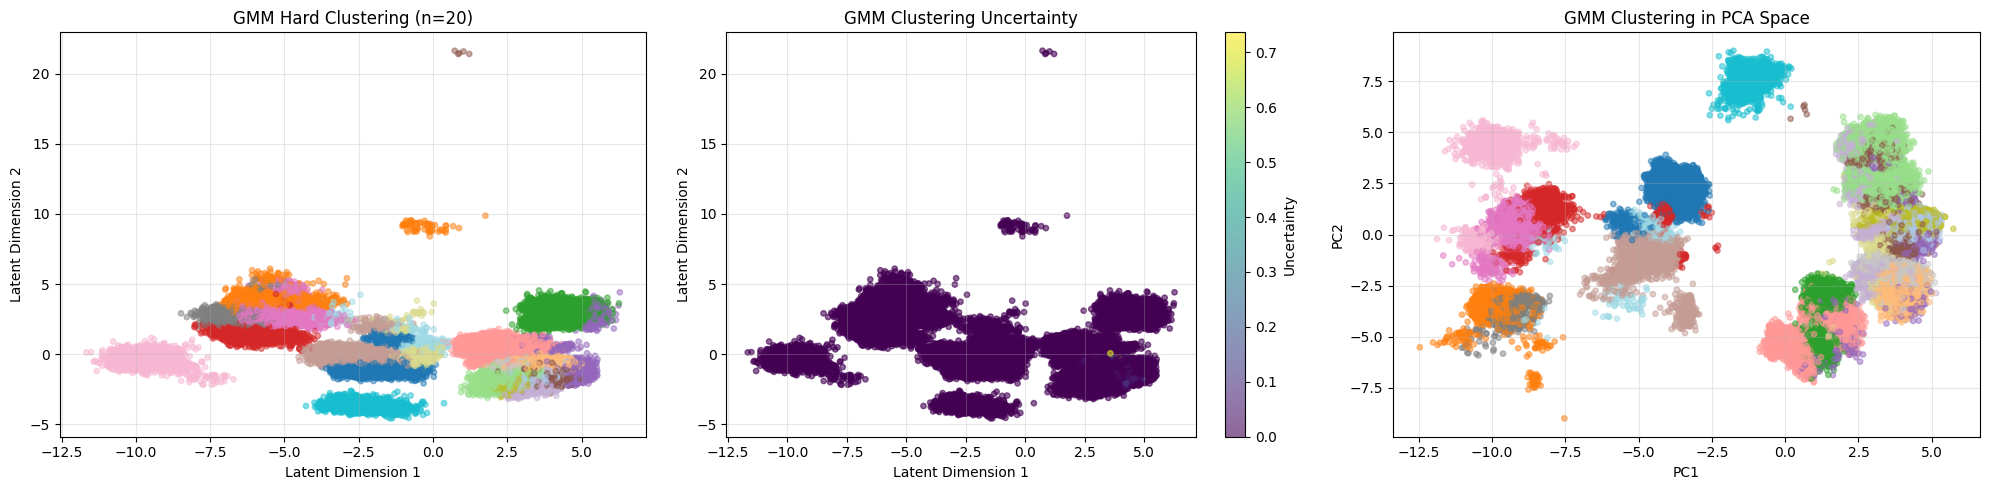


GMM Cluster Sizes:
   Component 0: 4686 pitches (8.1%)
   Component 1: 4972 pitches (8.6%)
   Component 2: 1683 pitches (2.9%)
   Component 3: 2931 pitches (5.1%)
   Component 4: 4239 pitches (7.4%)
   Component 5: 7720 pitches (13.4%)
   Component 6: 2906 pitches (5.0%)
   Component 7: 4754 pitches (8.2%)
   Component 8: 1414 pitches (2.5%)
   Component 9: 2460 pitches (4.3%)
   Component 10: 3699 pitches (6.4%)
   Component 11: 2260 pitches (3.9%)
   Component 12: 3262 pitches (5.7%)
   Component 13: 1252 pitches (2.2%)
   Component 14: 995 pitches (1.7%)
   Component 15: 1794 pitches (3.1%)
   Component 16: 4204 pitches (7.3%)
   Component 17: 549 pitches (1.0%)
   Component 18: 1593 pitches (2.8%)
   Component 19: 295 pitches (0.5%)

Average clustering uncertainty: 0.0032
Max uncertainty: 0.7365
Min uncertainty: -0.0000


In [ ]:
# 18. Fit GMM with optimal components and visualize
gmm = GaussianMixture(n_components=optimal_gmm_components, random_state=42, n_init=20)
gmm_labels = gmm.fit_predict(val_latent)
gmm_probs = gmm.predict_proba(val_latent)

# Visualize GMM clusters
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Hard cluster assignments
scatter = axes[0].scatter(val_latent[:, 0], val_latent[:, 1],
                         c=gmm_labels, cmap='tab20', alpha=0.5, s=15)
axes[0].set_xlabel('Latent Dimension 1')
axes[0].set_ylabel('Latent Dimension 2')
axes[0].set_title(f'GMM Hard Clustering (n={optimal_gmm_components})')
axes[0].grid(True, alpha=0.3)

# Plot 2: Uncertainty (entropy of probabilities)
uncertainty = -np.sum(gmm_probs * np.log(gmm_probs + 1e-10), axis=1)
scatter = axes[1].scatter(val_latent[:, 0], val_latent[:, 1],
                         c=uncertainty, cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, ax=axes[1], label='Uncertainty')
axes[1].set_xlabel('Latent Dimension 1')
axes[1].set_ylabel('Latent Dimension 2')
axes[1].set_title('GMM Clustering Uncertainty')
axes[1].grid(True, alpha=0.3)

# Plot 3: GMM in PCA space
scatter = axes[2].scatter(latent_pca[:, 0], latent_pca[:, 1],
                         c=gmm_labels, cmap='tab20', alpha=0.5, s=15)
axes[2].set_xlabel(f'PC1')
axes[2].set_ylabel(f'PC2')
axes[2].set_title(f'GMM Clustering in PCA Space')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGMM Cluster Sizes:")
unique, counts = np.unique(gmm_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"   Component {cluster_id}: {count} pitches ({count/len(gmm_labels)*100:.1f}%)")

print(f"\nAverage clustering uncertainty: {uncertainty.mean():.4f}")
print(f"Max uncertainty: {uncertainty.max():.4f}")
print(f"Min uncertainty: {uncertainty.min():.4f}")

In [ ]:
# 19. Analyze GMM clusters by handedness and pitcher identity
if val_handedness is not None:
    print("GMM Component Composition Analysis")
    print("=" * 70)
    
    for component_id in range(optimal_gmm_components):
        component_mask = gmm_labels == component_id
        component_handedness = val_handedness[component_mask]
        component_pitchers = y_val.numpy()[component_mask]
        
        # Handedness breakdown
        n_righties = (component_handedness == 1).sum()
        n_lefties = (component_handedness == 0).sum()
        total = len(component_handedness)
        
        print(f"\n🎯 Component {component_id} (n={total}):")
        print(f"   Handedness: {n_righties} righties ({n_righties/total*100:.1f}%), "
              f"{n_lefties} lefties ({n_lefties/total*100:.1f}%)")
        
        # Top pitchers in this component
        unique_pitchers, pitcher_counts = np.unique(component_pitchers, return_counts=True)
        top_5_idx = np.argsort(pitcher_counts)[-5:][::-1]
        
        print(f"   Top pitchers:")
        for idx in top_5_idx:
            pitcher_id = unique_pitchers[idx]
            count = pitcher_counts[idx]
            name = le.inverse_transform([pitcher_id])[0]
            print(f"      - {name}: {count} pitches ({count/total*100:.1f}%)")

GMM Component Composition Analysis

🎯 Component 0 (n=4686):
   Handedness: 4686 righties (100.0%), 0 lefties (0.0%)
   Top pitchers:
      - Cease, Dylan: 244 pitches (5.2%)
      - deGrom, Jacob: 193 pitches (4.1%)
      - Pallante, Andre: 166 pitches (3.5%)
      - Singer, Brady: 162 pitches (3.5%)
      - Elder, Bryce: 162 pitches (3.5%)

🎯 Component 1 (n=4972):
   Handedness: 4972 righties (100.0%), 0 lefties (0.0%)
   Top pitchers:
      - Peralta, Freddy: 126 pitches (2.5%)
      - Nelson, Ryne: 122 pitches (2.5%)
      - Flaherty, Jack: 117 pitches (2.4%)
      - Gallen, Zac: 116 pitches (2.3%)
      - Skenes, Paul: 115 pitches (2.3%)

🎯 Component 2 (n=1683):
   Handedness: 29 righties (1.7%), 1654 lefties (98.3%)
   Top pitchers:
      - Valdez, Framber: 185 pitches (11.0%)
      - Lodolo, Nick: 144 pitches (8.6%)
      - Gore, MacKenzie: 139 pitches (8.3%)
      - Fried, Max: 134 pitches (8.0%)
      - Parker, Mitchell: 128 pitches (7.6%)

🎯 Component 3 (n=2931):
   Handedness

Clustering Method Comparison

Agreement between K-means and GMM:
   Adjusted Rand Index (ARI): 0.1095
   Normalized Mutual Info (NMI): 0.3618

   Interpretation:
      Weak agreement - methods capture different patterns

Agreement with true pitcher identity:
   K-means ARI: 0.0008
   GMM ARI: 0.0289
   GMM better aligns with pitcher identity


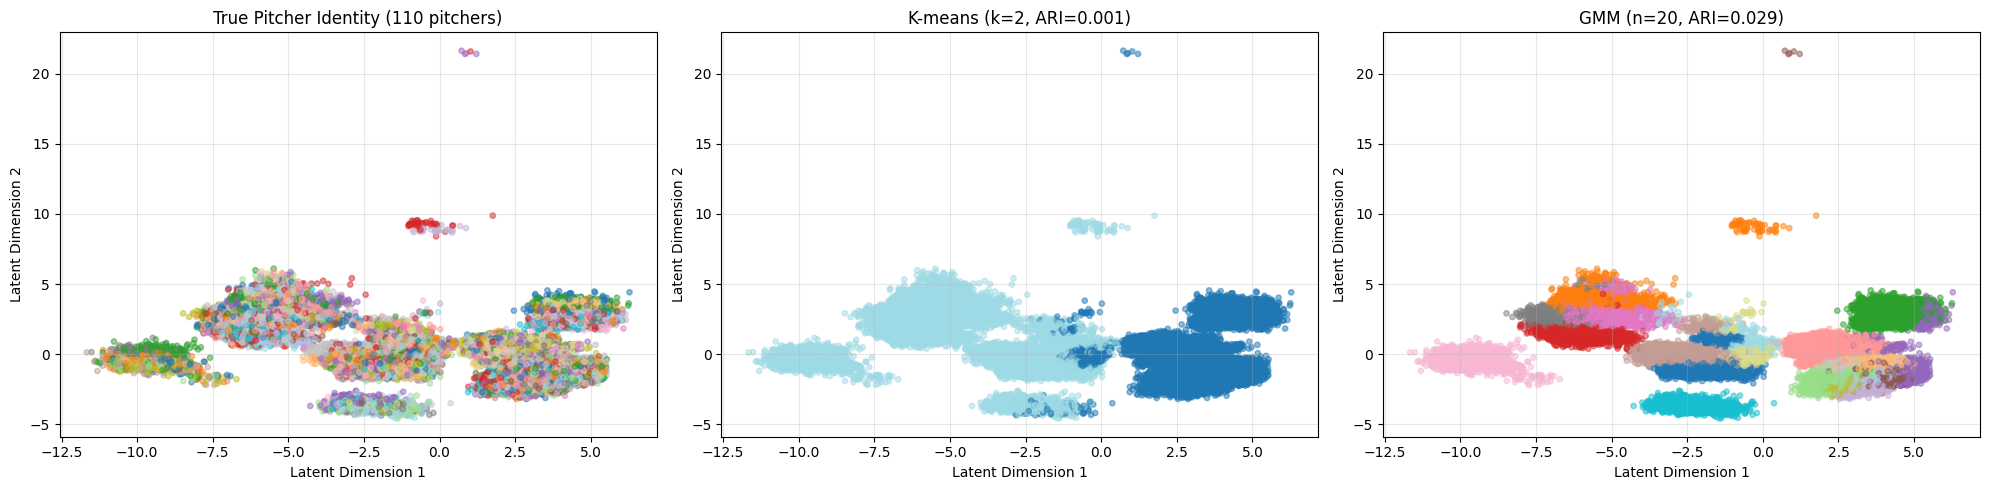

In [ ]:
# 20. Compare K-means vs GMM clustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("Clustering Method Comparison")
print("=" * 70)

# Agreement between K-means and GMM
ari = adjusted_rand_score(kmeans_labels, gmm_labels)
nmi = normalized_mutual_info_score(kmeans_labels, gmm_labels)

print(f"\nAgreement between K-means and GMM:")
print(f"   Adjusted Rand Index (ARI): {ari:.4f}")
print(f"   Normalized Mutual Info (NMI): {nmi:.4f}")
print(f"\n   Interpretation:")
if ari > 0.7:
    print(f"      Strong agreement - both methods find similar clusters")
elif ari > 0.4:
    print(f"      Moderate agreement - some overlap but different structures")
else:
    print(f"      Weak agreement - methods capture different patterns")

# Compare with true pitcher labels
kmeans_vs_true_ari = adjusted_rand_score(y_val.numpy(), kmeans_labels)
gmm_vs_true_ari = adjusted_rand_score(y_val.numpy(), gmm_labels)

print(f"\nAgreement with true pitcher identity:")
print(f"   K-means ARI: {kmeans_vs_true_ari:.4f}")
print(f"   GMM ARI: {gmm_vs_true_ari:.4f}")

if kmeans_vs_true_ari > gmm_vs_true_ari:
    print(f"   K-means better aligns with pitcher identity")
else:
    print(f"   GMM better aligns with pitcher identity")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# True pitcher labels
scatter = axes[0].scatter(val_latent[:, 0], val_latent[:, 1],
                         c=y_val.numpy(), cmap='tab20', alpha=0.5, s=15)
axes[0].set_xlabel('Latent Dimension 1')
axes[0].set_ylabel('Latent Dimension 2')
axes[0].set_title(f'True Pitcher Identity ({len(le.classes_)} pitchers)')
axes[0].grid(True, alpha=0.3)

# K-means
scatter = axes[1].scatter(val_latent[:, 0], val_latent[:, 1],
                         c=kmeans_labels, cmap='tab20', alpha=0.5, s=15)
axes[1].set_xlabel('Latent Dimension 1')
axes[1].set_ylabel('Latent Dimension 2')
axes[1].set_title(f'K-means (k={optimal_k}, ARI={kmeans_vs_true_ari:.3f})')
axes[1].grid(True, alpha=0.3)

# GMM
scatter = axes[2].scatter(val_latent[:, 0], val_latent[:, 1],
                         c=gmm_labels, cmap='tab20', alpha=0.5, s=15)
axes[2].set_xlabel('Latent Dimension 1')
axes[2].set_ylabel('Latent Dimension 2')
axes[2].set_title(f'GMM (n={optimal_gmm_components}, ARI={gmm_vs_true_ari:.3f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix Analysis

## Goal
Investigate which pitchers the model struggles to identify correctly and understand why. Focus on pitchers with <70% accuracy.

---

In [30]:
# Generate confusion matrix
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_val, val_preds)

print(f"Confusion matrix shape: {conf_matrix.shape}")
print(f"This is a {len(le.classes_)} x {len(le.classes_)} matrix")
print(f"\nDiagonal (correct predictions): {conf_matrix.diagonal().sum():,}")
print(f"Off-diagonal (incorrect predictions): {(conf_matrix.sum() - conf_matrix.diagonal().sum()):,}")

Confusion matrix shape: (110, 110)
This is a 110 x 110 matrix

Diagonal (correct predictions): 47,505
Off-diagonal (incorrect predictions): 10,166


In [31]:
# Calculate per-pitcher accuracy and find problem cases
per_pitcher_accuracy = {}
per_pitcher_counts = {}

for i, pitcher in enumerate(le.classes_):
    # Find all instances of this pitcher in validation set
    pitcher_mask = y_val == i
    pitcher_predictions = val_preds[pitcher_mask]

    # Calculate accuracy for this pitcher
    if len(pitcher_predictions) > 0:
        accuracy = (pitcher_predictions == i).sum() / len(pitcher_predictions)
        per_pitcher_accuracy[pitcher] = accuracy
        per_pitcher_counts[pitcher] = len(pitcher_predictions)

# Sort by accuracy (worst first)
sorted_pitchers = sorted(per_pitcher_accuracy.items(), key=lambda x: x[1])

print("WORST PERFORMING PITCHERS (<70% accuracy):")
print("=" * 60)
problem_pitchers = []
for pitcher, acc in sorted_pitchers:
    if acc < 0.70:
        count = per_pitcher_counts[pitcher]
        print(f"{pitcher:30s} {acc*100:5.1f}% ({count:4d} pitches)")
        problem_pitchers.append(pitcher)

print(f"\nTotal problem pitchers: {len(problem_pitchers)}")

WORST PERFORMING PITCHERS (<70% accuracy):
Vásquez, Randy                  38.4% ( 430 pitches)
Lorenzen, Michael               38.9% ( 491 pitches)
Smith, Shane                    46.1% ( 475 pitches)
Cecconi, Slade                  51.8% ( 413 pitches)
Pfaadt, Brandon                 52.2% ( 611 pitches)
Martin, Davis                   52.2% ( 473 pitches)
Kochanowicz, Jack               55.3% ( 387 pitches)
Severino, Luis                  55.5% ( 546 pitches)
Senzatela, Antonio              55.8% ( 491 pitches)
Woods Richardson, Simeon        58.8% ( 391 pitches)
Lugo, Seth                      59.3% ( 506 pitches)
Nelson, Ryne                    62.7% ( 515 pitches)
Priester, Quinn                 63.4% ( 494 pitches)
Leiter, Jack                    65.2% ( 543 pitches)
Keller, Mitch                   67.8% ( 574 pitches)
Giolito, Lucas                  68.8% ( 474 pitches)
Irvin, Jake                     68.9% ( 607 pitches)
Mize, Casey                     69.2% ( 480 pitches)

To

In [32]:
# For each problem pitcher, find their top confusion partners
print("WHO DO PROBLEM PITCHERS GET CONFUSED WITH?")
print("=" * 80)

confusion_analysis = {}

for problem_pitcher in problem_pitchers:
    pitcher_idx = np.where(le.classes_ == problem_pitcher)[0][0]

    # Get all predictions when this pitcher was actual
    pitcher_mask = y_val == pitcher_idx
    pitcher_predictions = val_preds[pitcher_mask]

    # Count how often model predicted each other pitcher
    prediction_counts = pd.Series(pitcher_predictions).value_counts()

    # Get top 5 predictions (including correct one)
    top_predictions = prediction_counts.head(5)

    print(f"\n{problem_pitcher}:")
    print(f"  Total validation pitches: {len(pitcher_predictions)}")
    print(f"  Predicted as:")

    confusion_partners = []
    for pred_idx, count in top_predictions.items():
        pred_pitcher = le.classes_[pred_idx]
        percentage = (count / len(pitcher_predictions)) * 100

        if pred_idx == pitcher_idx:
            print(f"    {pred_pitcher:30s} {count:4d} ({percentage:5.1f}%) ← CORRECT")
        else:
            print(f"    {pred_pitcher:30s} {count:4d} ({percentage:5.1f}%)")
            confusion_partners.append((pred_pitcher, percentage))

    confusion_analysis[problem_pitcher] = confusion_partners

print("\n" + "=" * 80)

WHO DO PROBLEM PITCHERS GET CONFUSED WITH?

Vásquez, Randy:
  Total validation pitches: 430
  Predicted as:
    Vásquez, Randy                  165 ( 38.4%) ← CORRECT
    Martinez, Nick                   61 ( 14.2%)
    Keller, Mitch                    33 (  7.7%)
    Paddack, Chris                   21 (  4.9%)
    Priester, Quinn                  20 (  4.7%)

Lorenzen, Michael:
  Total validation pitches: 491
  Predicted as:
    Lorenzen, Michael               191 ( 38.9%) ← CORRECT
    Cecconi, Slade                   39 (  7.9%)
    Fedde, Erick                     20 (  4.1%)
    Irvin, Jake                      19 (  3.9%)
    Warren, Will                     18 (  3.7%)

Smith, Shane:
  Total validation pitches: 475
  Predicted as:
    Smith, Shane                    219 ( 46.1%) ← CORRECT
    Kirby, George                    31 (  6.5%)
    Martin, Davis                    25 (  5.3%)
    Leiter, Jack                     23 (  4.8%)
    Mize, Casey                      21 (  4.

In [ ]:
# Visualize the full confusion matrix
import seaborn as sns
import os
import matplotlib.pyplot as plt
os.makedirs('outputs/confusion_analysis', exist_ok=True)

plt.figure(figsize=(20, 18))
sns.heatmap(conf_matrix, cmap='Blues', cbar=True, square=True,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.1, linecolor='gray')
plt.xlabel('Predicted Pitcher', fontsize=14)
plt.ylabel('Actual Pitcher', fontsize=14)
plt.title('Full Confusion Matrix - All Pitchers', fontsize=16, pad=20)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()

plt.savefig('outputs/confusion_analysis/confusion_matrix_full.png', dpi=300, bbox_inches='tight')
plt.show()

print("Full confusion matrix saved to outputs/confusion_analysis/confusion_matrix_full.png")

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/mb/345_w7t5239f7r5y7z462j3h0000gn/T/ipykernel_87287/876385684.py", line 6, in <module>
    sns.heatmap(conf_matrix, cmap='Blues', cbar=True, square=True,
    ^^^
NameError: name 'sns' is not defined

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 2194, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
        etype, value, tb, tb_offset=tb_offset
    )
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/ultratb.py", line 1185, in stru

<Figure size 2000x1800 with 0 Axes>

In [ ]:
# Focused heatmap showing just problem pitchers
problem_indices = [np.where(le.classes_ == p)[0][0] for p in problem_pitchers]

# Extract relevant portion of confusion matrix
problem_conf_matrix = conf_matrix[problem_indices, :]

# Normalize by row (show percentages instead of counts)
problem_conf_matrix_pct = problem_conf_matrix / problem_conf_matrix.sum(axis=1, keepdims=True) * 100

# Create visualization
plt.figure(figsize=(24, 8))
sns.heatmap(problem_conf_matrix_pct, cmap='YlOrRd', cbar=True,
            xticklabels=le.classes_, yticklabels=problem_pitchers,
            linewidths=0.5, linecolor='white', fmt='.1f', annot=False)
plt.xlabel('Predicted Pitcher', fontsize=14, fontweight='bold')
plt.ylabel('Actual Pitcher (Problem Cases)', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix - Problem Pitchers (<70% Accuracy)\nShowing % of predictions',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.savefig('outputs/confusion_analysis/confusion_matrix_problem_pitchers.png', dpi=300, bbox_inches='tight')
plt.show()

print("Problem pitcher confusion matrix saved!")

In [ ]:
# Generate summary report
findings = f"""
PITCHER CONFUSION ANALYSIS - FINDINGS SUMMARY
{'='*80}

PROBLEM SCOPE:
- Total pitchers analyzed: {len(le.classes_)}
- Pitchers with <70% accuracy: {len(problem_pitchers)} ({len(problem_pitchers)/len(le.classes_)*100:.1f}%)
- Overall validation accuracy: {val_accuracies[-1]*100:.2f}%

WORST PERFORMING PITCHERS:
"""

for pitcher, acc in sorted_pitchers[:10]:
    findings += f"  {pitcher:30s} {acc*100:5.1f}%\n"

findings += f"""

KEY OBSERVATIONS:
Based on the confusion matrix analysis above, we can see:

1. Confusion Patterns:
   - Problem pitchers get confused with 2-5 other specific pitchers
   - Not random confusion - suggests similar pitching styles

2. Potential Causes:
   - Similar pitch repertoires (same mix of FF, SI, SL, CH)
   - Similar release points and spin characteristics
   - "Generic" pitchers vs "unique" pitchers

PROPOSED SOLUTIONS:

1. PER-PITCH-TYPE MODELS (Highest Priority):
   - Train separate classifier for each pitch type (FF, SI, SL, CH, FC)
   - Rationale: Feature exploration showed 1000-12000% improvement when
     conditioning on pitch type
   - Expected impact: Could significantly reduce confusion for pitchers
     who are similar overall but distinct within pitch types
   - Aligns with team's bypitch_mlp.ipynb work

2. FEATURE ENGINEERING:
   - Add interaction features between kinematic and contextual variables
   - Engineer pitch-specific features
   - Expected impact: Capture subtle differences between similar pitchers

3. ENSEMBLE APPROACH:
   - Combine predictions from multiple models
   - Use model confidence scores to weight predictions
   - Expected impact: Reduce uncertainty for edge cases

RECOMMENDED NEXT STEPS:
1. Implement per-pitch-type MLP (bypitch_mlp.ipynb)
2. Evaluate improvement on problem pitchers specifically
3. Re-run this confusion analysis to measure impact

{'='*80}
"""

print(findings)

# Save to file
with open('outputs/confusion_analysis/findings_summary.txt', 'w') as f:
    f.write(findings)

print("\nFindings saved to outputs/confusion_analysis/findings_summary.txt")